In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../beam_search_summary.csv")
df

,dataset,beam_width,k,avg_edges_1.0,train_relevant_1.0,train_seen_1.0,train_expanded_1.0,avg_edges_0.995,train_relevant_0.995,train_seen_0.995,...,train_seen_0.815,train_expanded_0.815,avg_edges_0.81,train_relevant_0.81,train_seen_0.81,train_expanded_0.81,avg_edges_0.805,train_relevant_0.805,train_seen_0.805,train_expanded_0.805
0,mnist,1,1,19.637517,1.0000,154.5700,8.9100,9.319767,0.4100,87.2400,...,15.4200,6.3900,2.724333,0.0100,15.4200,6.3400,2.689333,0.0100,15.8400,6.6000
1,mnist,1,10,19.637517,1.0000,154.5700,8.9100,9.319767,0.4900,87.2400,...,15.4200,6.3900,2.724333,0.0100,15.4200,6.3400,2.689333,0.0100,15.8400,6.6000
2,mnist,1,100,19.637517,1.0000,154.5700,8.9100,9.319767,0.6200,87.2400,...,15.4200,6.3900,2.724333,0.0500,15.4200,6.3400,2.689333,0.0500,15.8400,6.6000
3,mnist,2,1,19.637517,1.0000,167.6400,9.6500,9.319767,0.7200,114.3800,...,27.5300,11.1600,2.724333,0.0300,27.6200,11.1200,2.689333,0.0400,28.5200,11.5100
4,mnist,2,10,19.637517,2.0000,167.6400,9.6500,9.319767,1.5900,114.3800,...,27.5300,11.1600,2.724333,0.1100,27.6200,11.1200,2.689333,0.1300,28.5200,11.5100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,glove25,128,10,50.408023,9.9888,5844.9188,133.0049,7.294107,8.1813,1159.4052,...,390.3806,181.7411,1.927580,0.6206,383.8036,181.9747,1.907492,0.5442,377.4968,181.8186
146,glove25,128,100,50.408023,97.1300,5844.9188,133.0049,7.294107,74.5897,1159.4052,...,390.3806,181.7411,1.927580,6.3824,383.8036,181.9747,1.907492,5.6570,377.4968,181.8186
147,glove25,256,1,50.408023,1.0000,10479.2726,260.6352,7.294107,0.7448,1979.7641,...,681.4677,342.4708,1.927580,0.0554,669.7409,342.2988,1.907492,0.0490,659.9581,342.4923
148,glove25,256,10,50.408023,9.9988,10479.2726,260.6352,7.294107,8.5284,1979.7641,...,681.4677,342.4708,1.927580,1.0380,669.7409,342.2988,1.907492,0.9382,659.9581,342.4923


In [ ]:
import re

plt.style.use('default')

TRAIN_COLOR = 'black'

for _, row in df.iterrows():
    coverages = sorted(
        [float(re.search(r'avg_edges_(.+)', c).group(1))
         for c in df.columns if c.startswith('avg_edges_')],
        reverse=True
    )

    avg_edges      = [row[f'avg_edges_{v}']      for v in coverages]
    train_precision   = [row[f'train_relevant_{v}'] / min(row['beam_width'], 100) for v in coverages]
    train_seen     = [row[f'train_seen_{v}']     for v in coverages]
    train_expanded = [row[f'train_expanded_{v}'] for v in coverages]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"{row['dataset']}, beam width = {row['beam_width']}", fontsize=14, fontweight='bold')

    plot_specs = [
        {'ylabel': 'Avg. Precision',   'train_y': train_precision},
        {'ylabel': 'Avg. Edges',    'train_y': avg_edges},
        {'ylabel': 'Avg. Seen',     'train_y': train_seen},
        {'ylabel': 'Avg. Expanded', 'train_y': train_expanded},
    ]

    for ax, spec in zip(axes, plot_specs):
        ax.plot(coverages, spec['train_y'], color=TRAIN_COLOR, linewidth=1.5)
        for xi, yi in zip(coverages, spec['train_y']):
            ax.scatter(xi, yi, color=TRAIN_COLOR, s=10, zorder=5, linewidths=1.5)
            # ax.text(xi, yi, f'{xi}', ha='center', va='center', fontsize=5, color=TRAIN_COLOR, zorder=3)
        ax.set_xlabel('Coverage (navigability %)')
        ax.set_ylabel(spec['ylabel'])

    plt.tight_layout()
    plt.show()


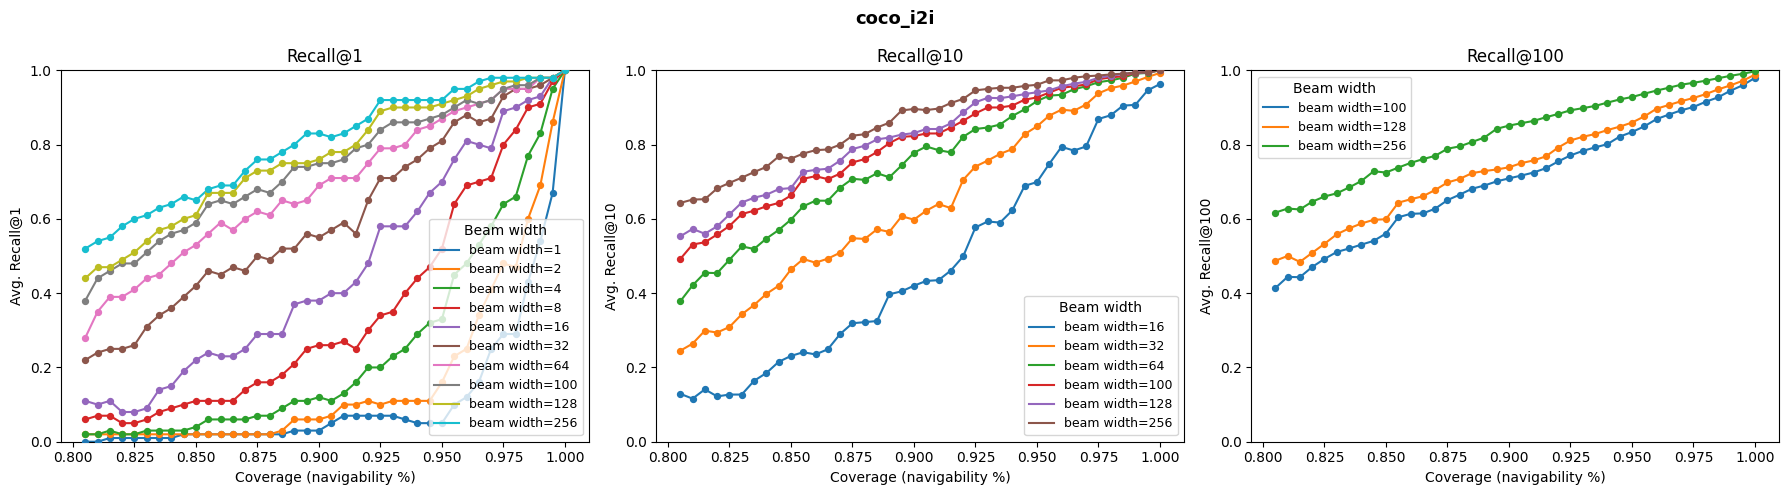

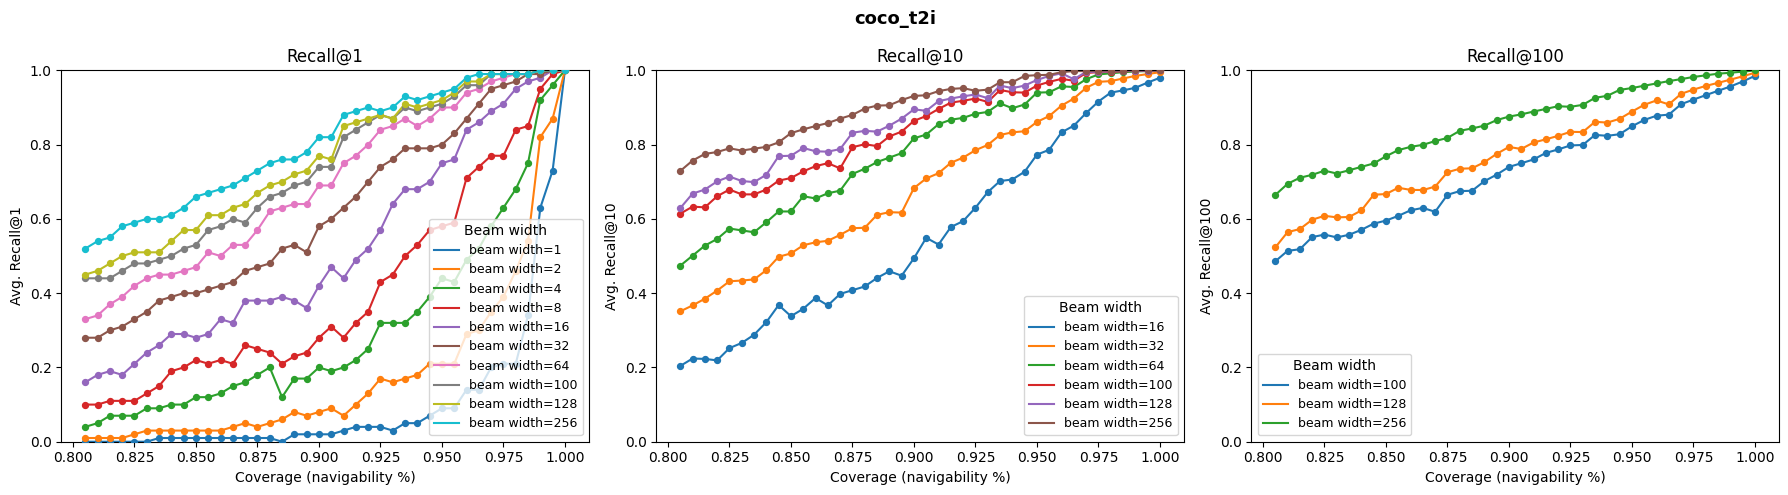

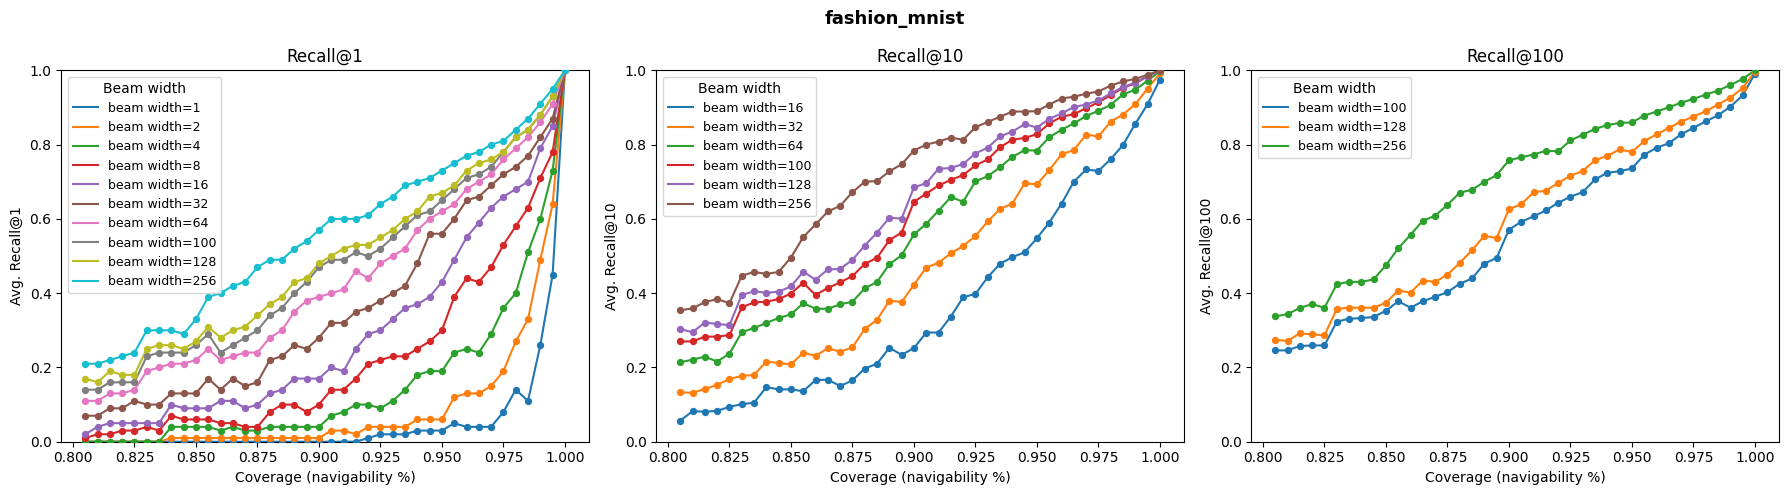

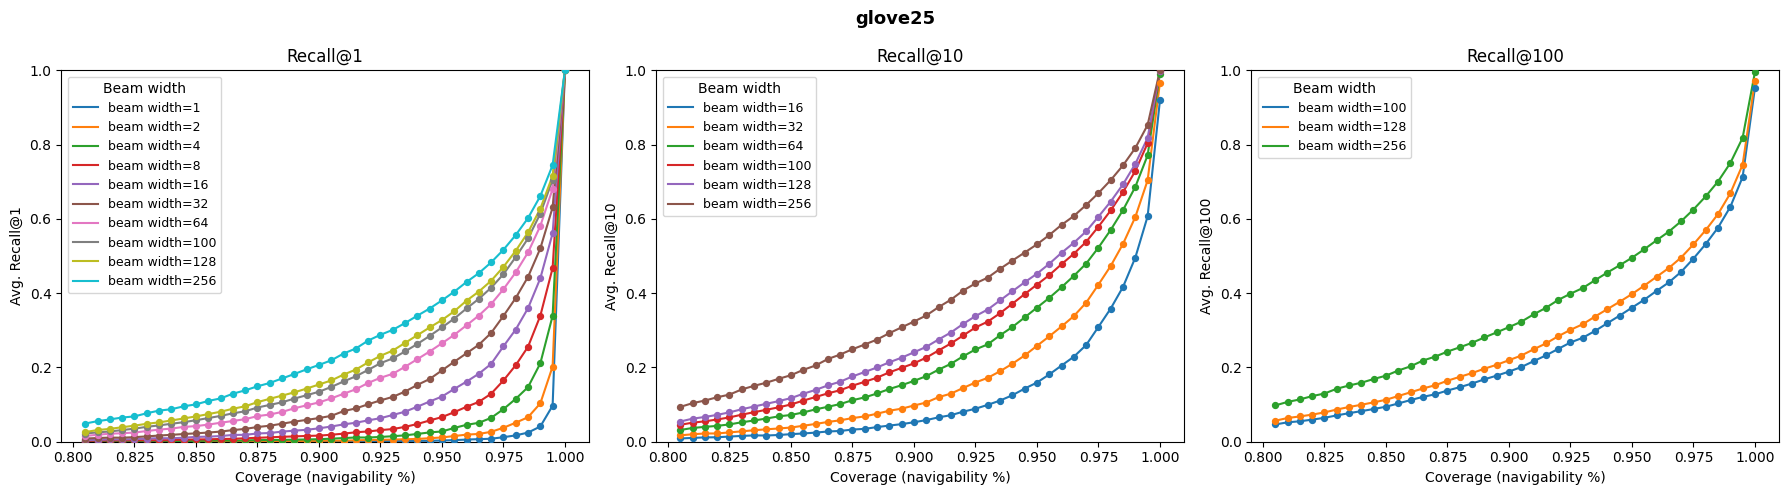

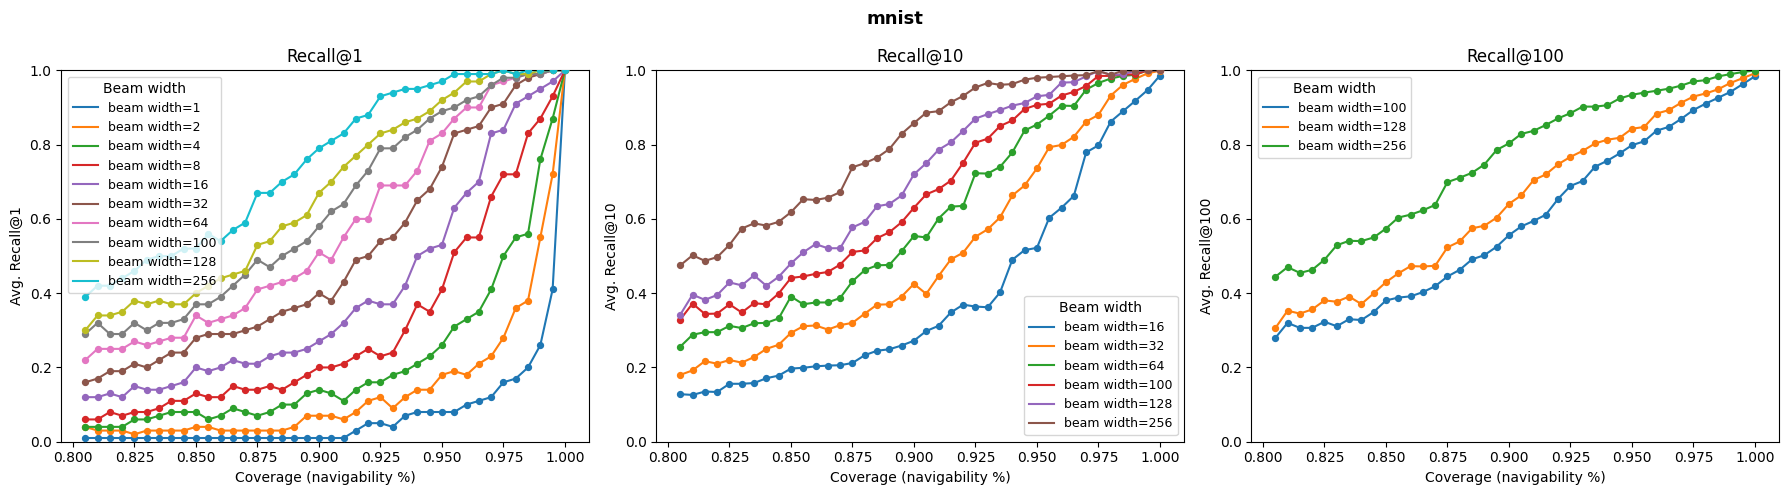

In [4]:
import re
import matplotlib.cm as cm

plt.style.use('default')

coverages = sorted(
    [float(re.search(r'avg_edges_(.+)', c).group(1))
     for c in df.columns if c.startswith('avg_edges_')],
    reverse=True
)

RECALL_KS = sorted(df['k'].unique())

for dataset, ds_df in df.groupby('dataset'):
    valid_ks = [k for k in RECALL_KS if not ds_df[(ds_df['k'] == k) & (ds_df['beam_width'] >= k)].empty]
    if not valid_ks:
        continue

    fig, axes = plt.subplots(1, len(valid_ks), figsize=(6 * len(valid_ks), 5))
    if len(valid_ks) == 1:
        axes = [axes]
    fig.suptitle(dataset, fontsize=13, fontweight='bold')

    for ax, k in zip(axes, valid_ks):
        k_df = ds_df[(ds_df['k'] == k) & (ds_df['beam_width'] >= k)]

        beam_widths = sorted(k_df['beam_width'].unique())
        colors      = cm.tab10.colors[:len(beam_widths)]
        color_map   = dict(zip(beam_widths, colors))

        for _, row in k_df.iterrows():
            bw    = row['beam_width']
            ys    = [row[f'train_relevant_{v}'] / row['k'] for v in coverages]
            ax.plot(coverages, ys, color=color_map[bw], linewidth=1.5, label=f'beam width={bw}')
            ax.scatter(coverages, ys, color=color_map[bw], s=18, zorder=5)

        ax.set_title(f'Recall@{k}')
        ax.set_xlabel('Coverage (navigability %)')
        ax.set_ylabel(f'Avg. Recall@{k}')
        ax.set_ylim(0,1)
        ax.legend(title='Beam width', fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.cm as cm

COVERAGE = '0.995'
K = 1

ds_df_k1 = df[(df['k'] == K) & (df['beam_width'] >= K)]

for dataset, ds_df in ds_df_k1.groupby('dataset'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'{dataset}  (coverage = {COVERAGE}, k={K})', fontsize=13, fontweight='bold')

    plot_specs = [
        (axes[0, 0], f'train_expanded_{COVERAGE}', None,                         'Avg. Expanded', f'Recall@{K}', True),
        (axes[0, 1], 'beam_width',                 f'train_expanded_{COVERAGE}', 'Beam Width',    'Avg. Expanded', False),
        (axes[1, 0], f'train_seen_{COVERAGE}',     None,                         'Avg. Seen',     f'Recall@{K}', True),
        (axes[1, 1], 'beam_width',                 f'train_seen_{COVERAGE}',     'Beam Width',    'Avg. Seen',   False),
    ]

    ds_df_sorted = ds_df.sort_values('beam_width')

    for ax, xcol, ycol, xlabel, ylabel, is_recall in plot_specs:
        xs = ds_df_sorted[xcol]
        ys = ds_df_sorted[f'train_relevant_{COVERAGE}'] / K if is_recall else ds_df_sorted[ycol]
        ax.plot(xs, ys, linewidth=1.5, marker='o', ms=4)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if is_recall:
            ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


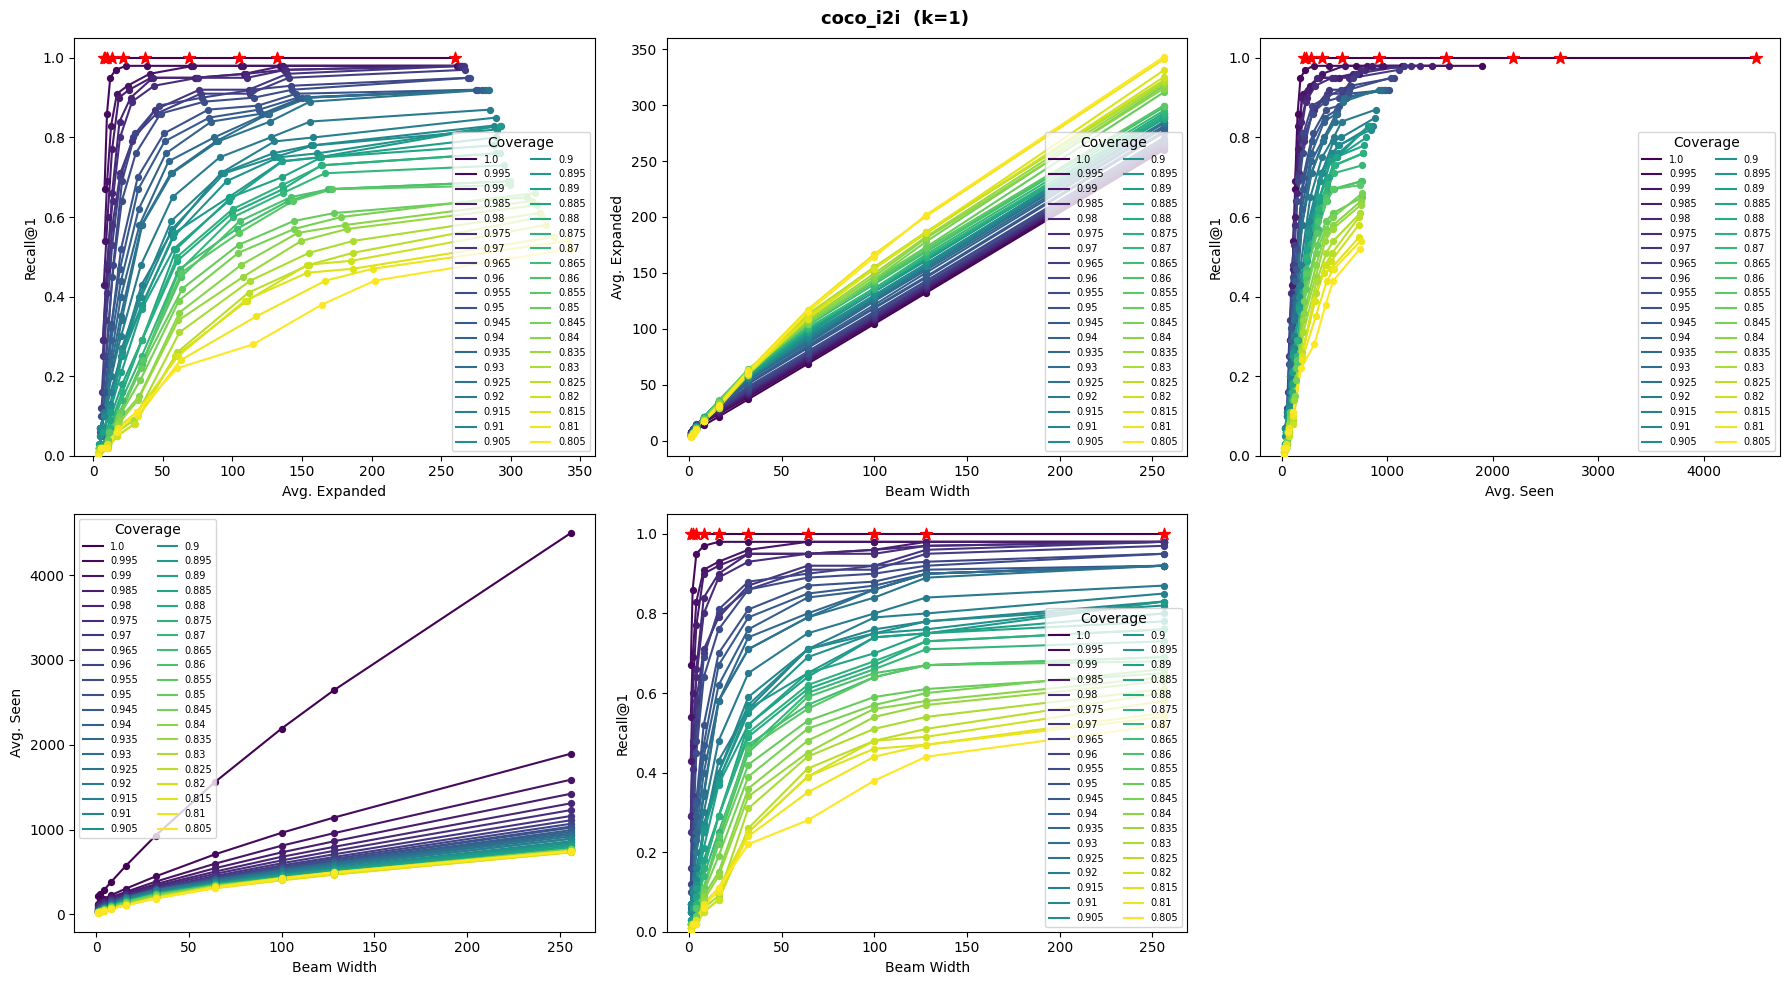

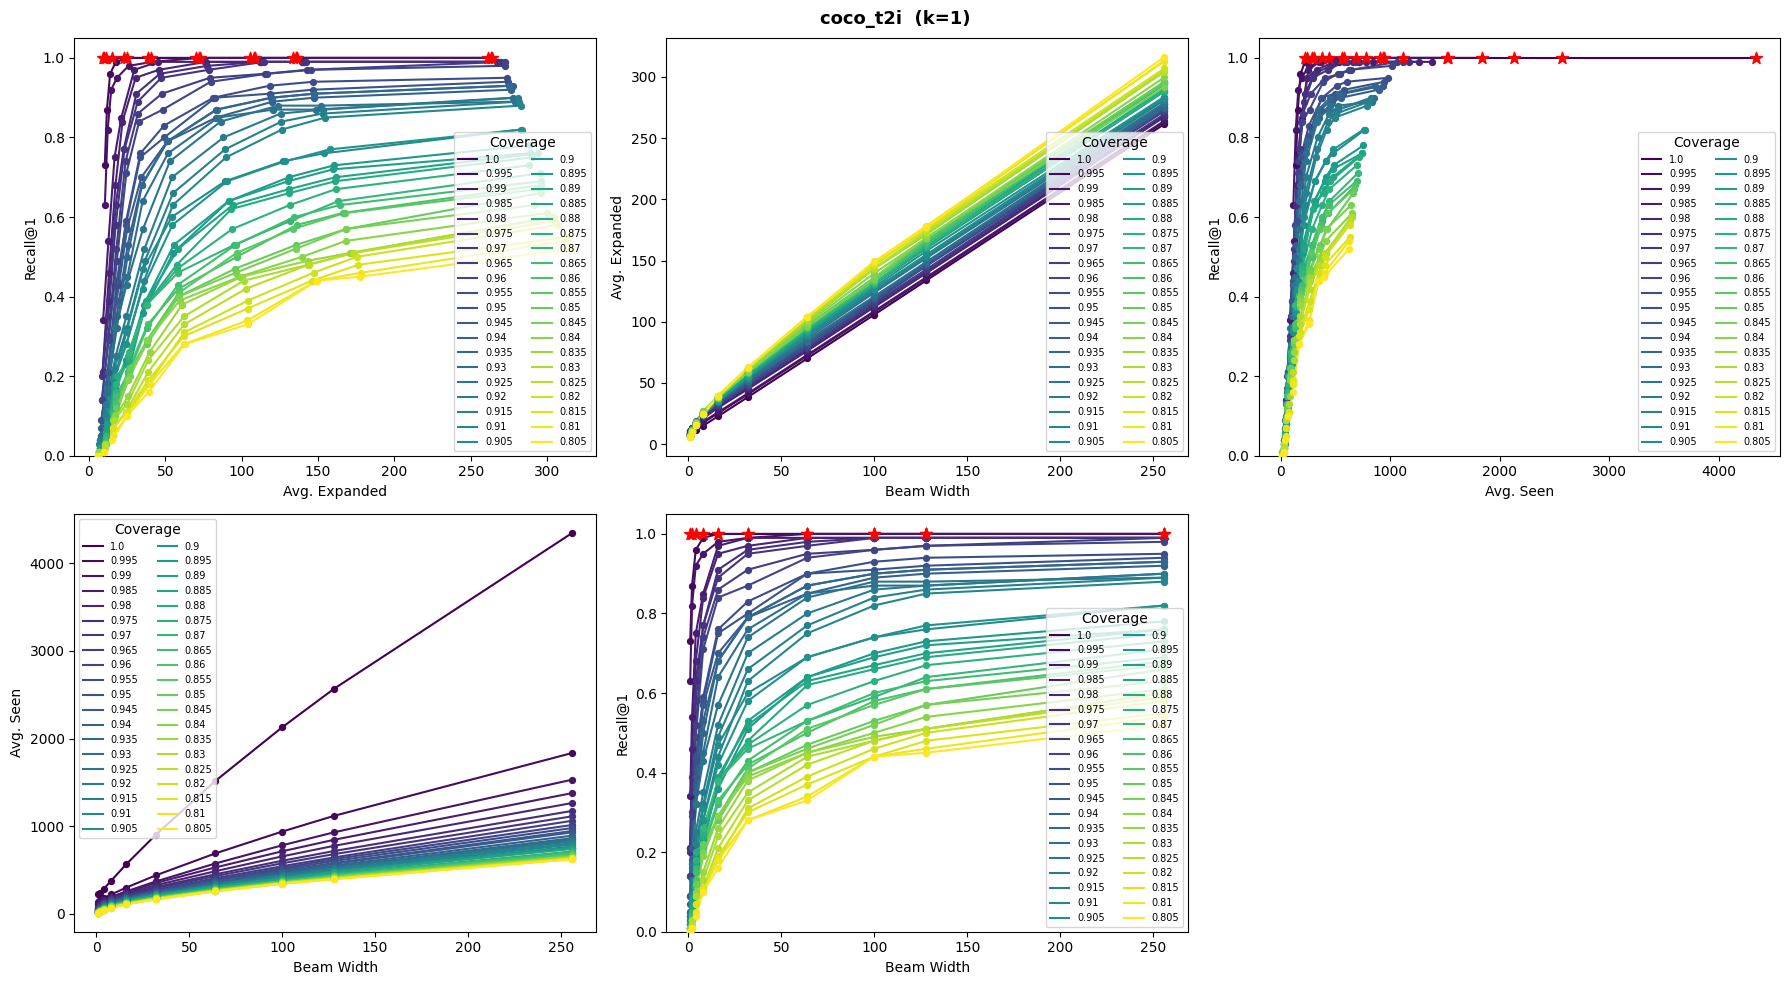

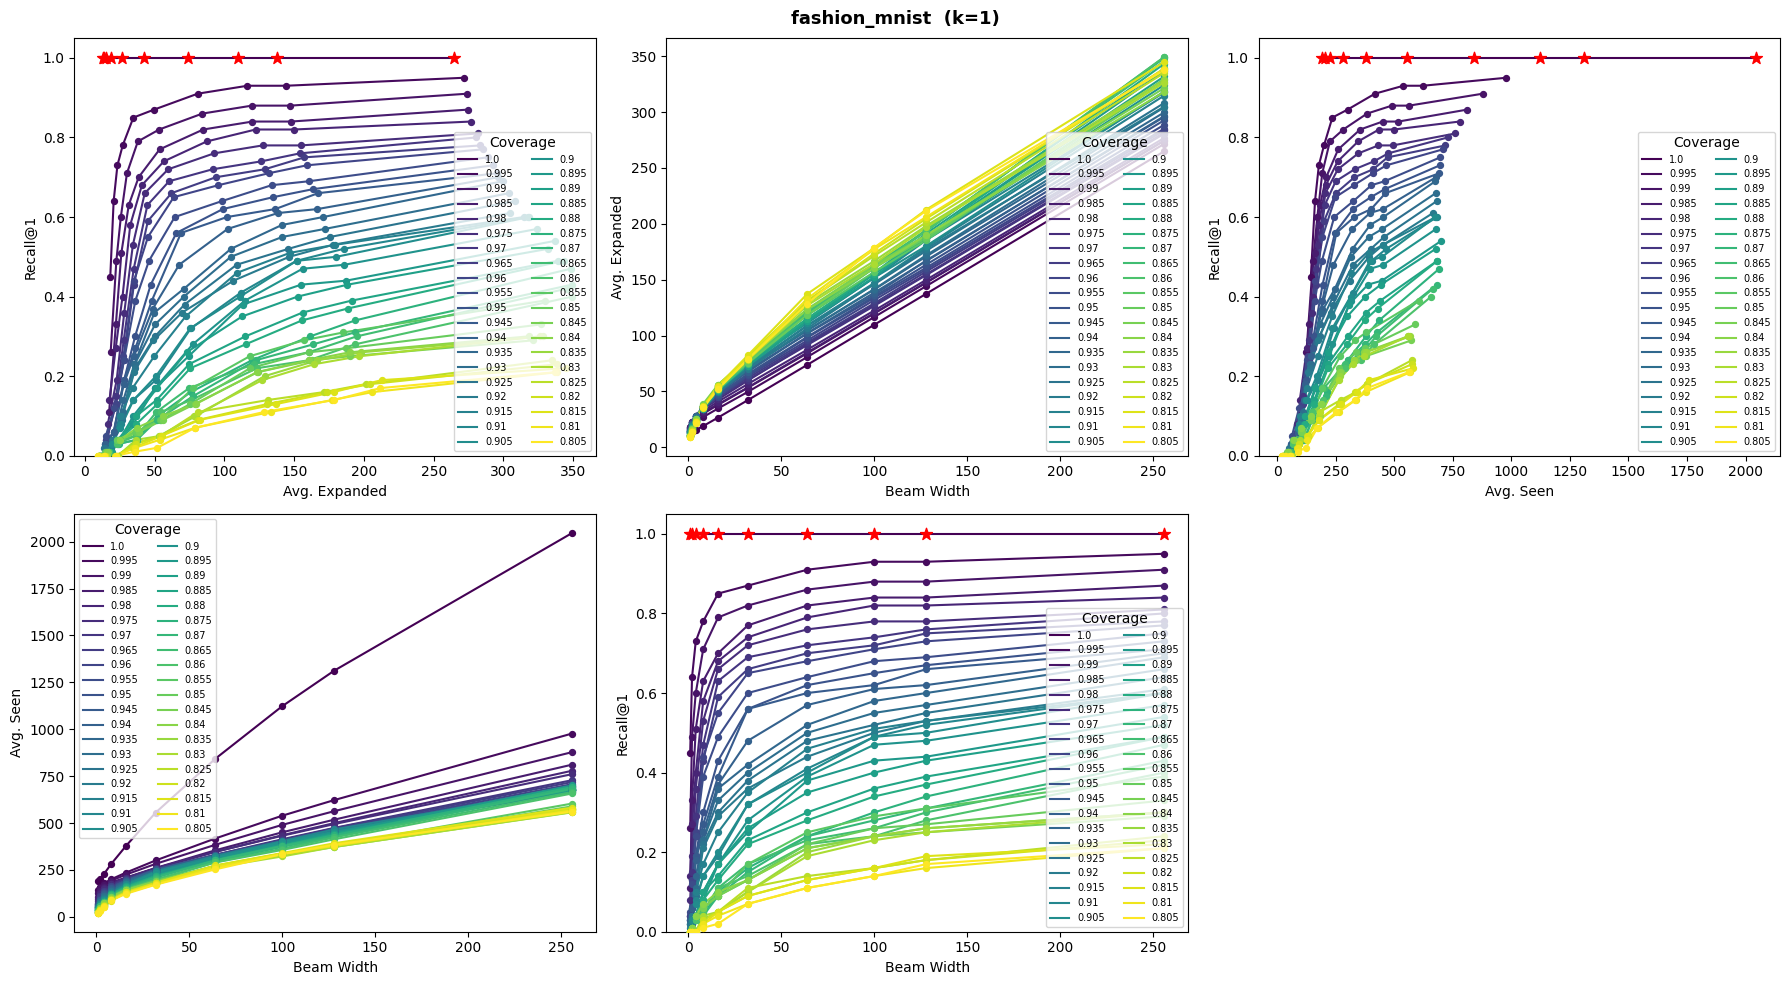

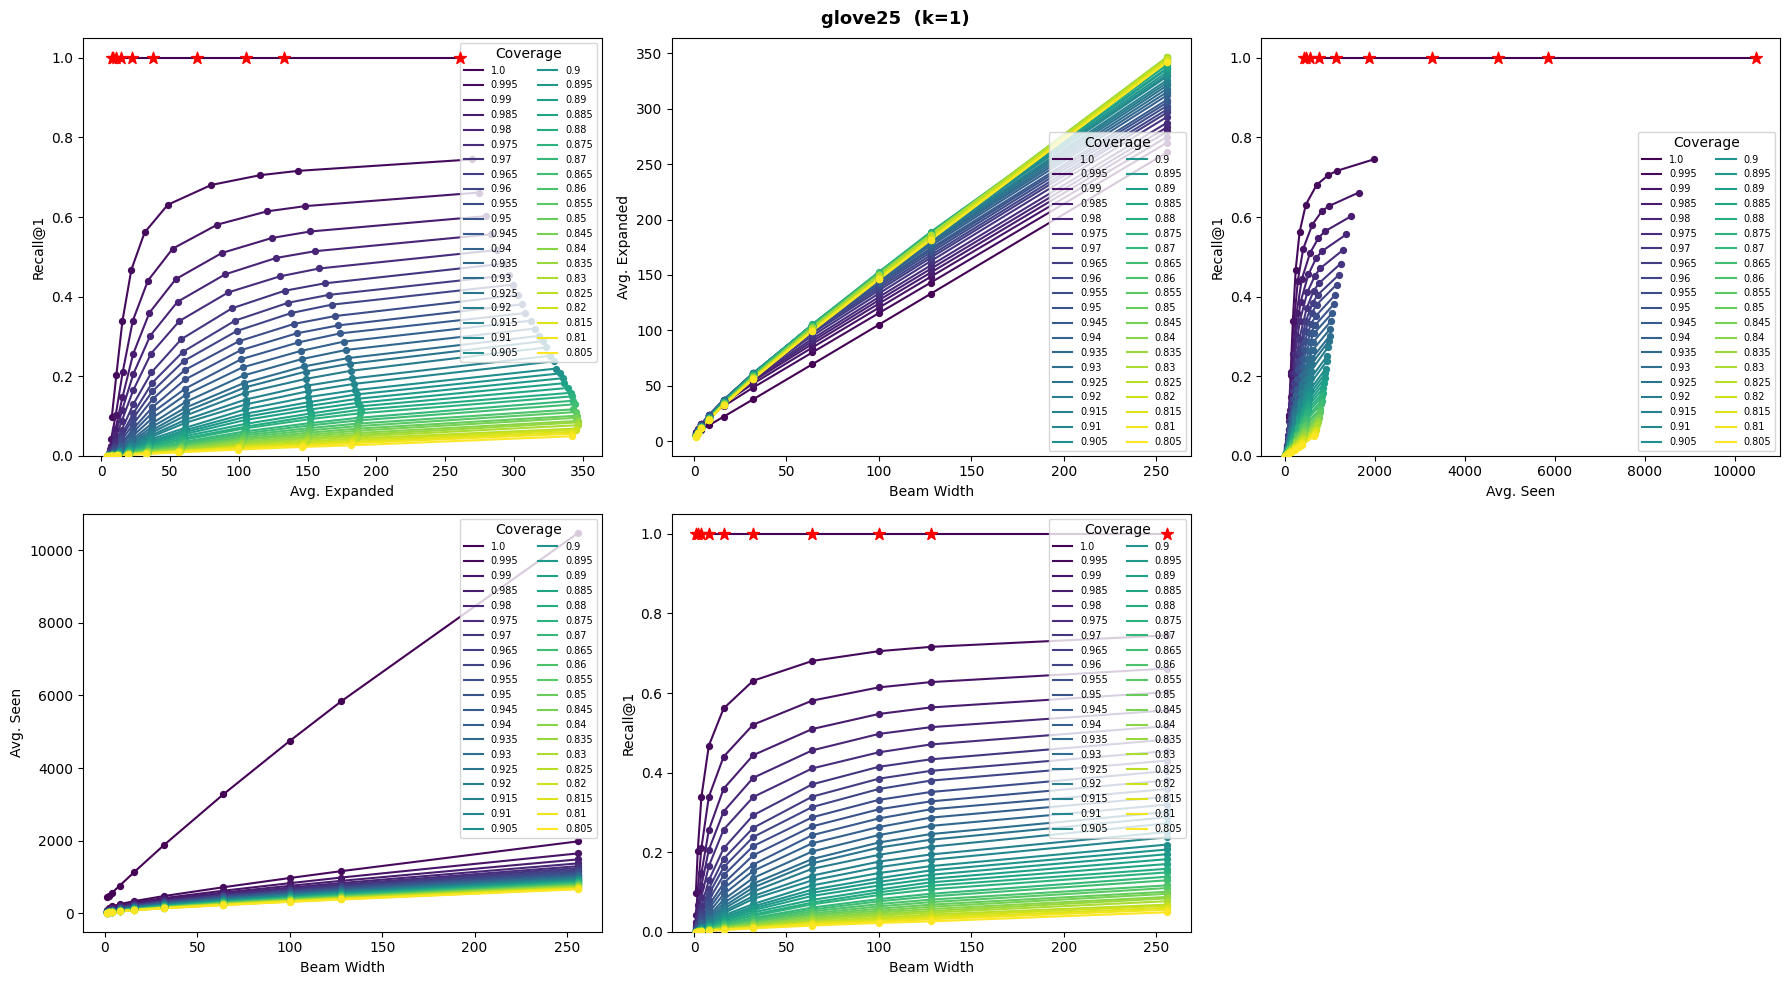

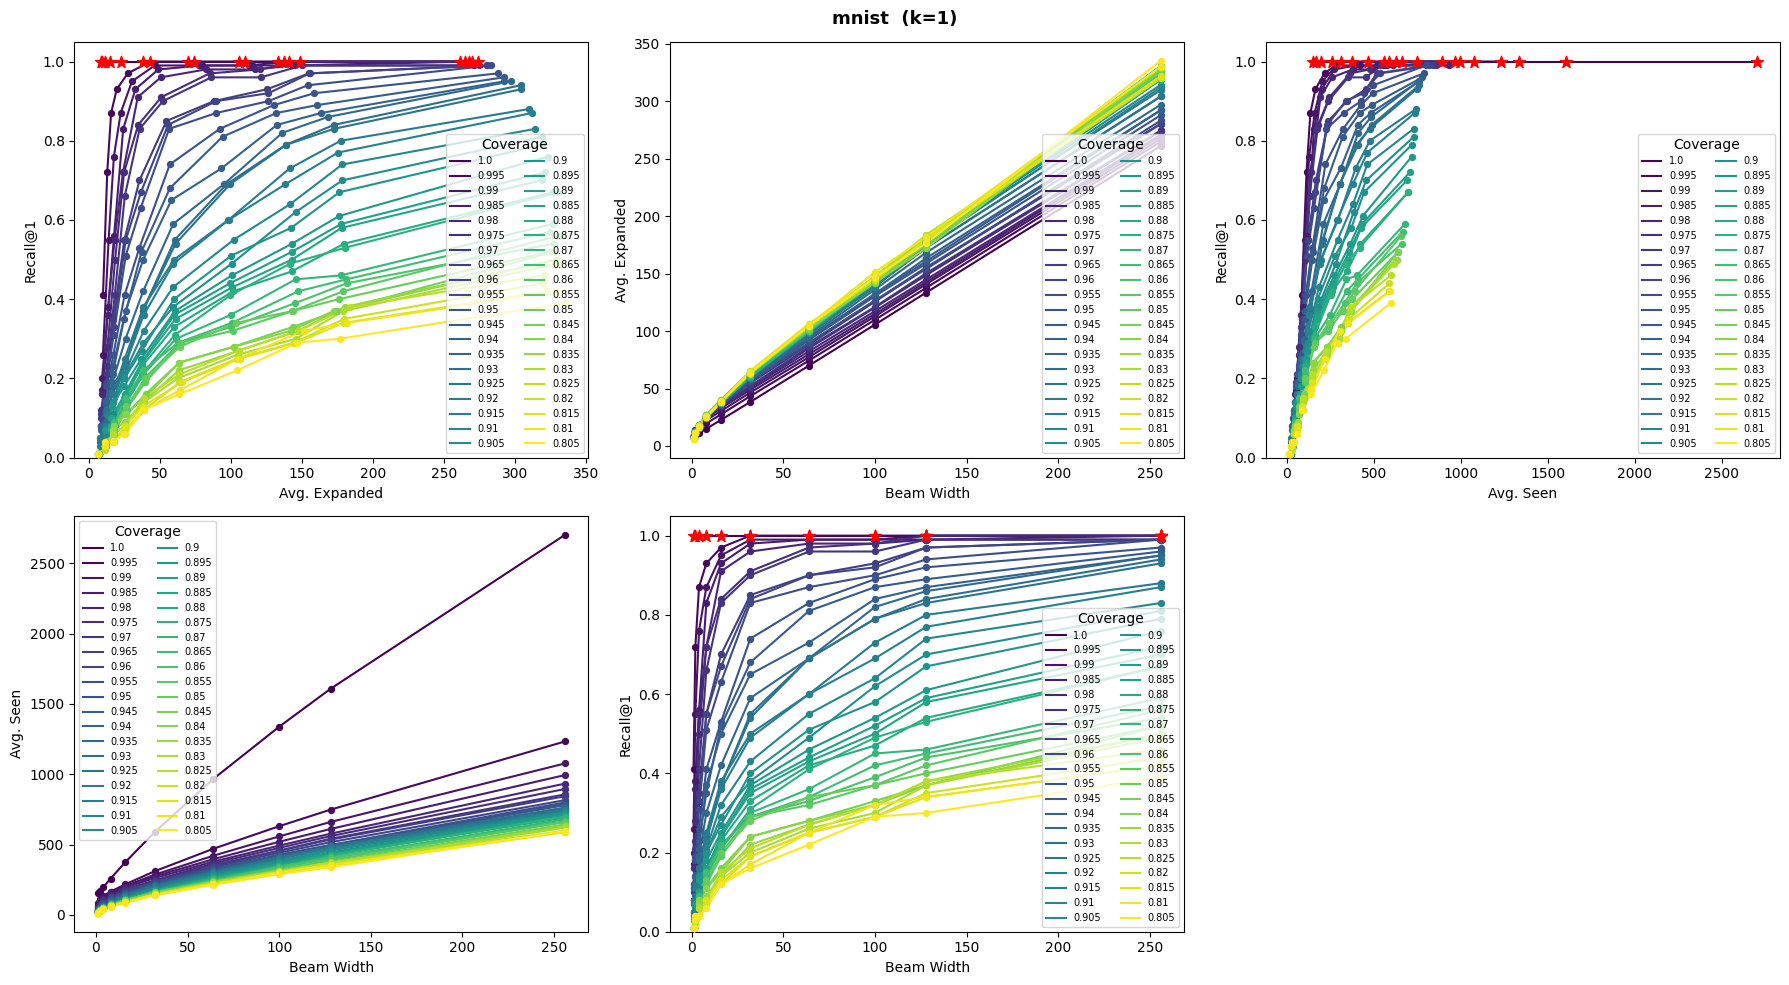

In [10]:
import matplotlib.cm as cm
import re

K = 1

ds_df_k1 = df[(df['k'] == K) & (df['beam_width'] >= K)]

coverages = sorted(
    [re.search(r'avg_edges_(.+)', c).group(1) for c in df.columns if c.startswith('avg_edges_')],
    reverse=True
)
cmap = cm.viridis
colors = [cmap(i / (len(coverages) - 1)) for i in range(len(coverages))]

plot_specs = [
    (f'train_expanded_{{c}}', None,                    'Avg. Expanded', f'Recall@{K}',    True),
    ('beam_width',            f'train_expanded_{{c}}', 'Beam Width',    'Avg. Expanded',  False),
    (f'train_seen_{{c}}',     None,                    'Avg. Seen',     f'Recall@{K}',    True),
    ('beam_width',            f'train_seen_{{c}}',     'Beam Width',    'Avg. Seen',       False),
    ('beam_width',            None,                    'Beam Width',    f'Recall@{K}',    True),
]

for dataset, ds_df in ds_df_k1.groupby('dataset'):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{dataset}  (k={K})', fontsize=13, fontweight='bold')
    axes[-1, -1].set_visible(False)

    axes_flat = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

    for ax, (xcol_t, ycol_t, xlabel, ylabel, is_recall) in zip(axes_flat, plot_specs):
        for c, color in zip(coverages, colors):
            ds_df_sorted = ds_df.sort_values('beam_width')
            xcol = xcol_t.replace('{c}', c)
            xs = ds_df_sorted[xcol].values
            ys = (ds_df_sorted[f'train_relevant_{c}'] / K if is_recall else ds_df_sorted[ycol_t.replace('{c}', c)]).values
            ax.plot(xs, ys, color=color, linewidth=1.5, label=c)

            if is_recall:
                star_mask = ys >= 1
                reg_mask  = ~star_mask
                if reg_mask.any():
                    ax.scatter(xs[reg_mask], ys[reg_mask], color=color, s=18, zorder=5)
                if star_mask.any():
                    ax.scatter(xs[star_mask], ys[star_mask], marker='*', color='red', s=80, zorder=6)
            else:
                ax.scatter(xs, ys, color=color, s=18, zorder=5)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if is_recall:
            ax.set_ylim(0, 1.05)
        ax.legend(title='Coverage', fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()


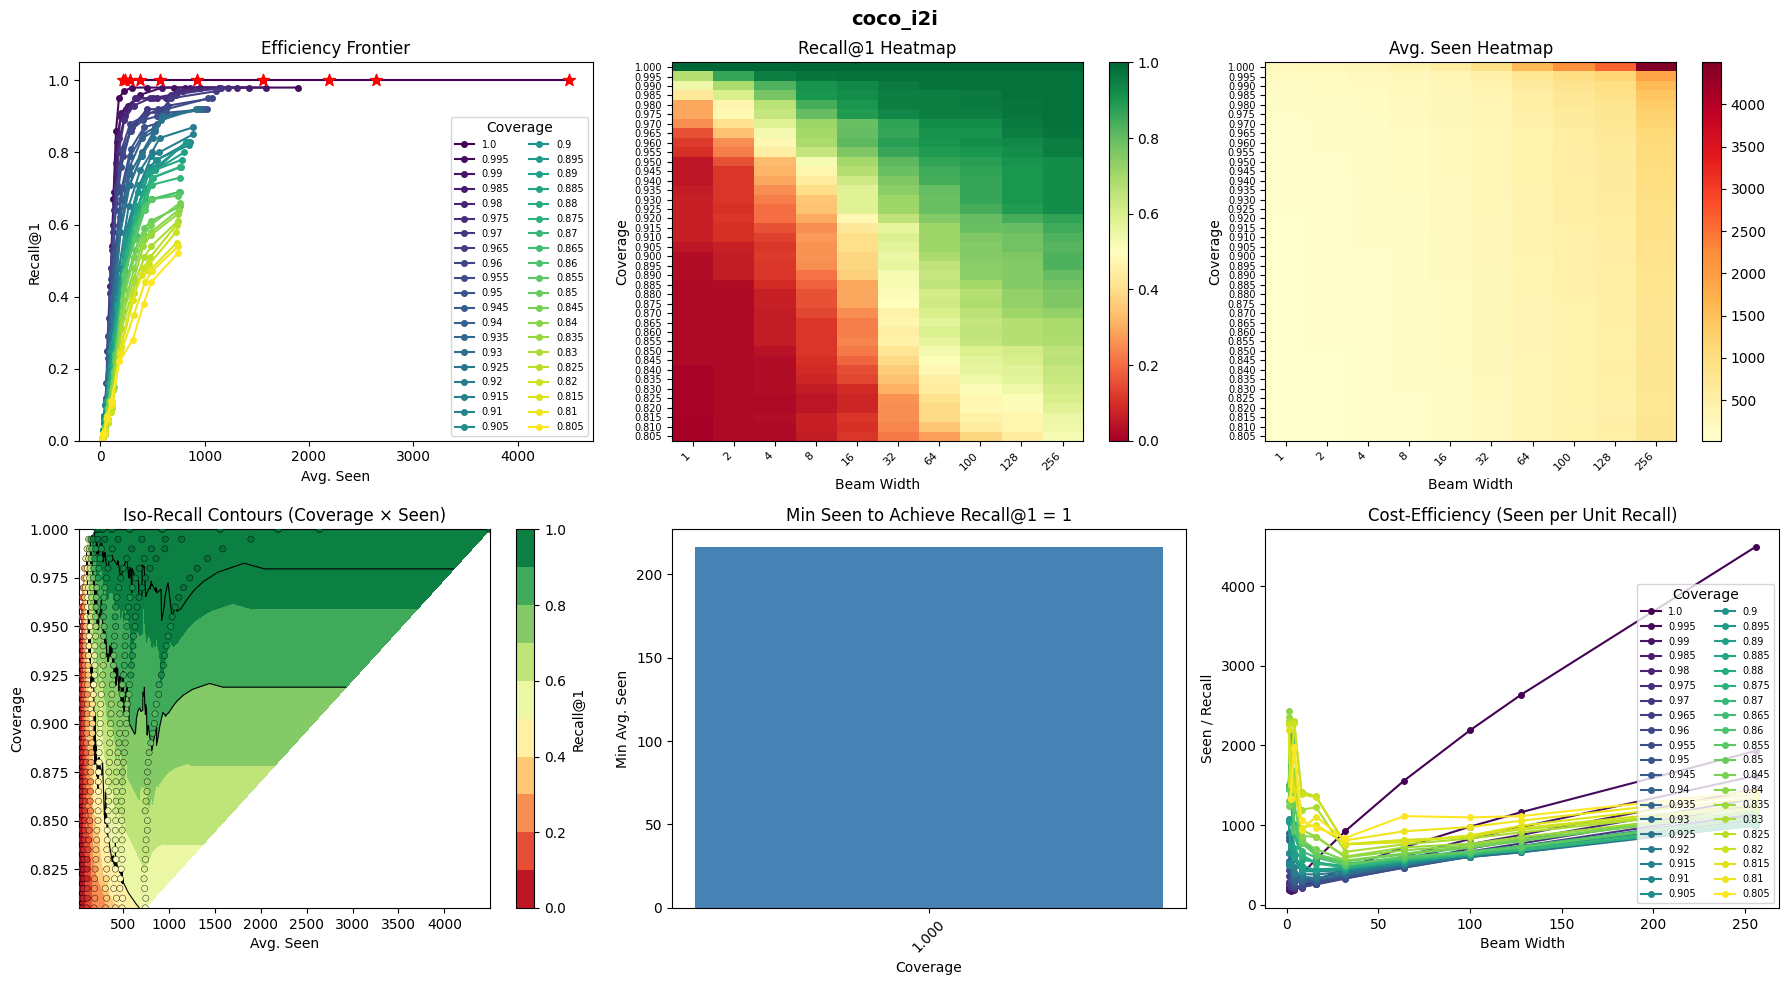

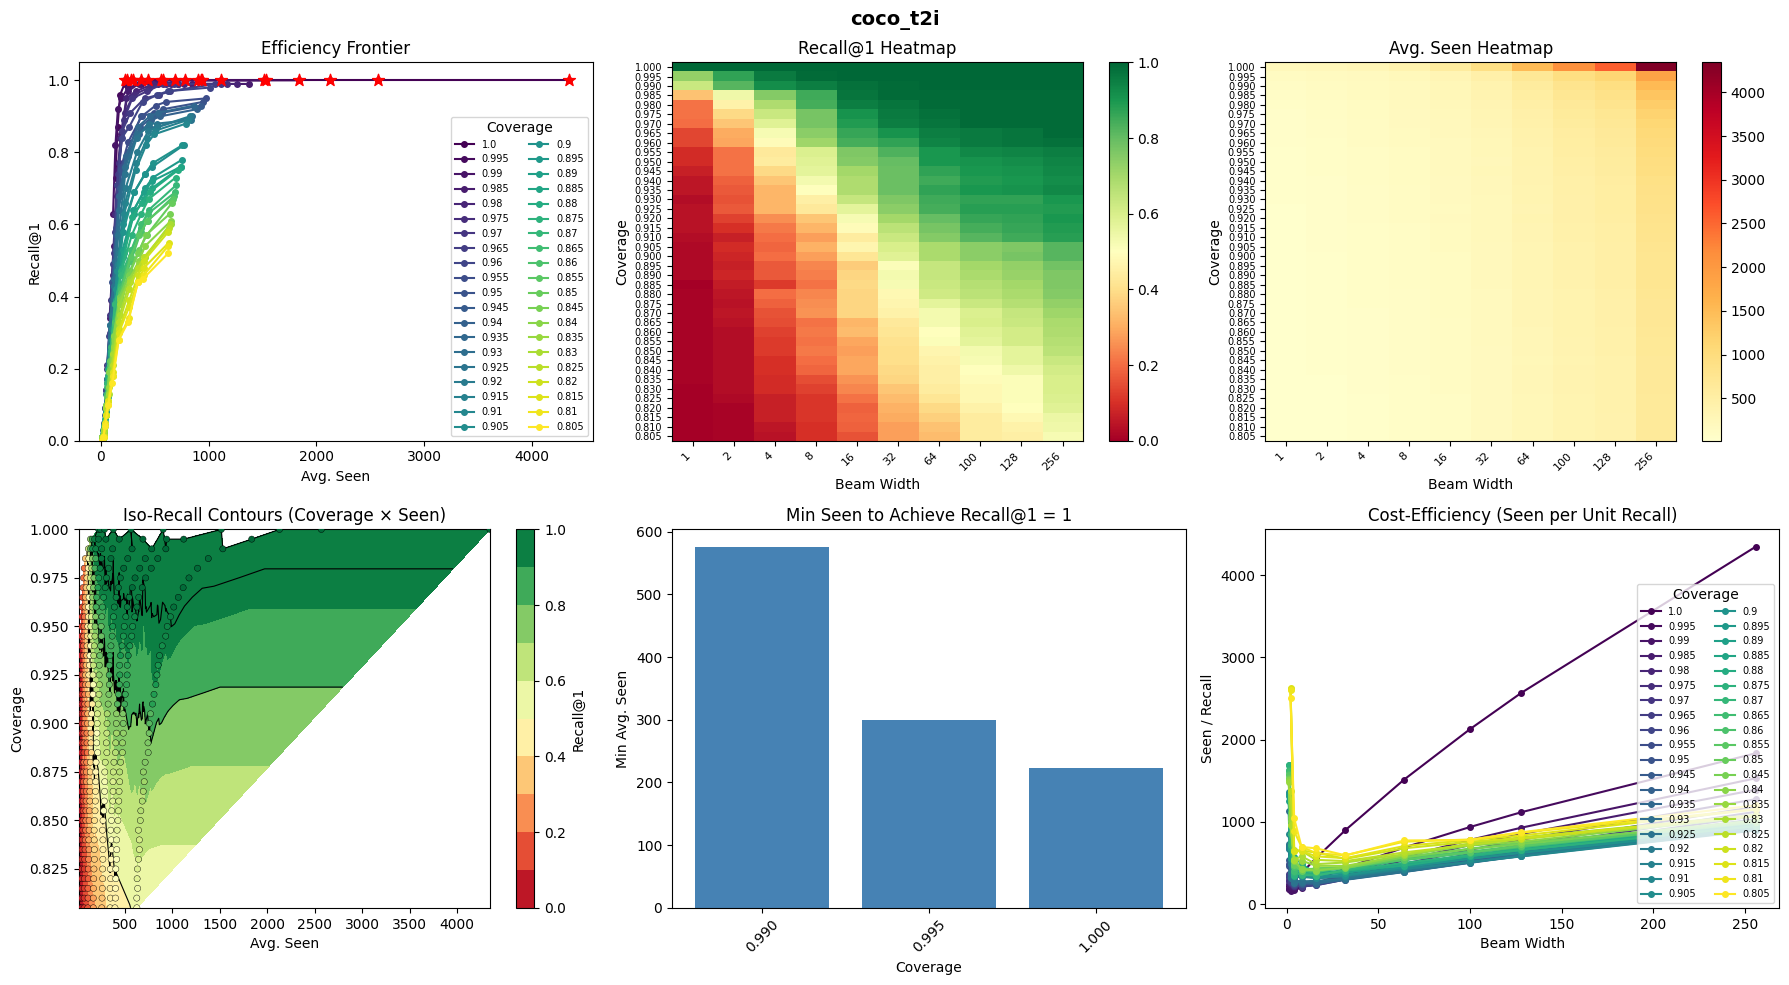

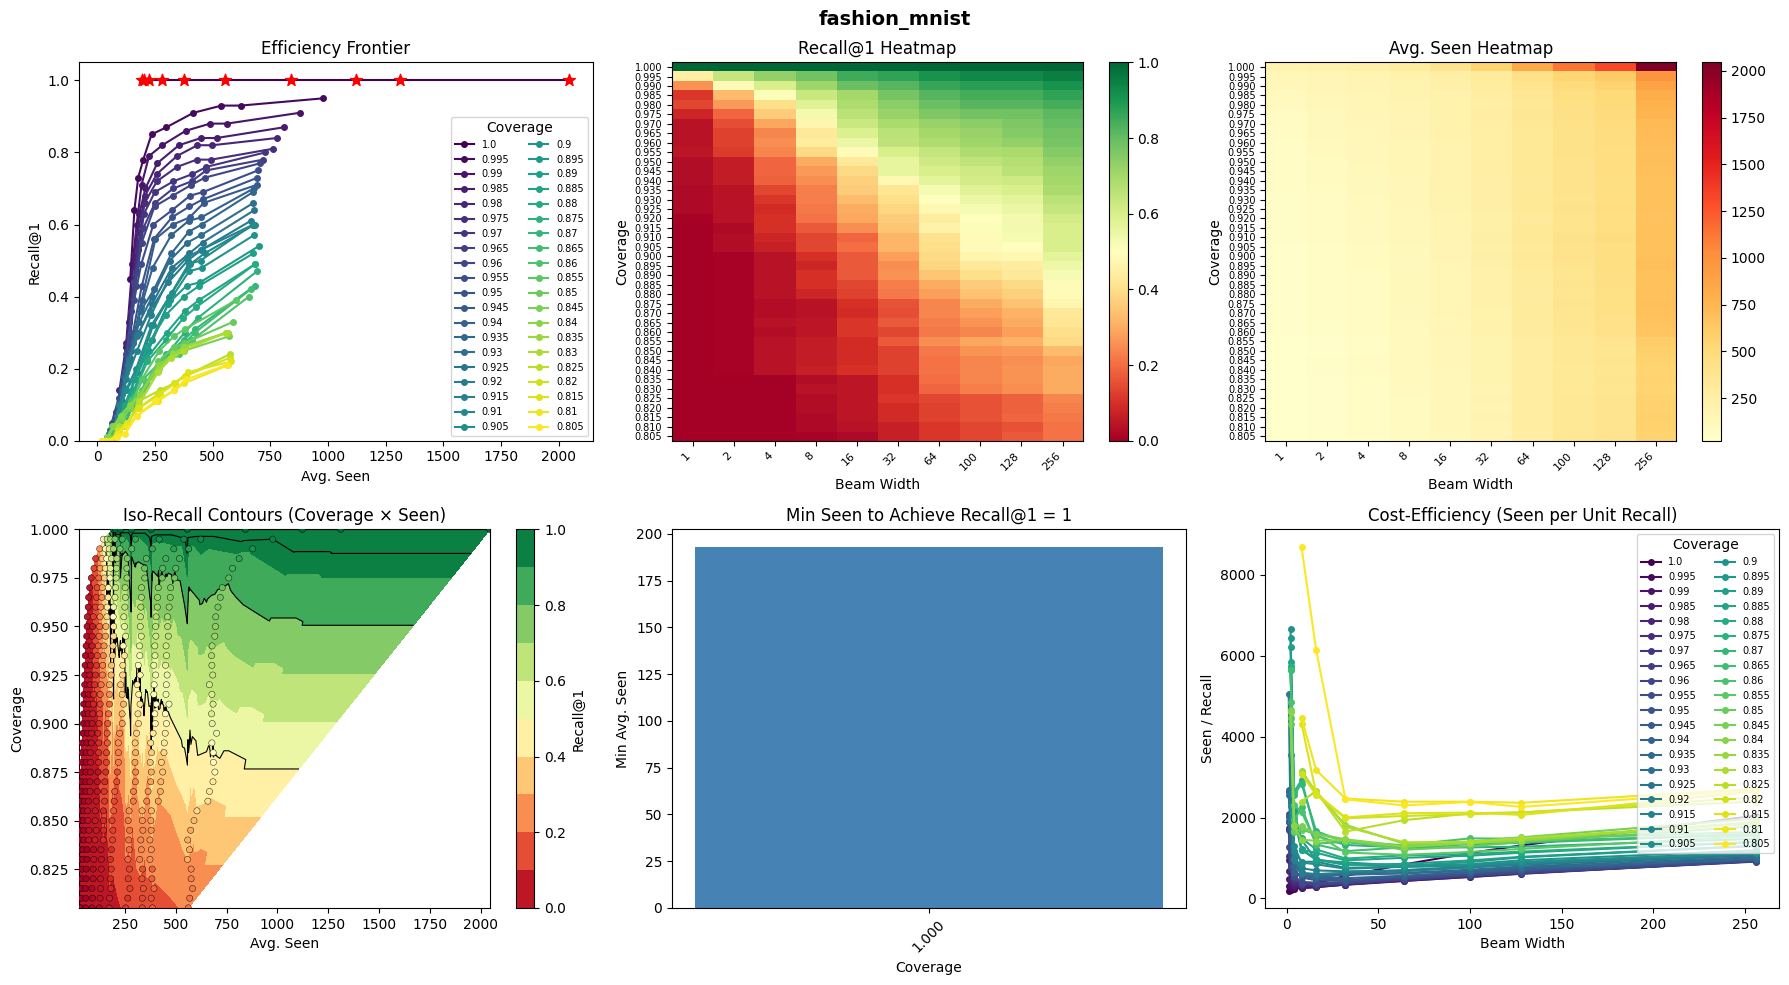

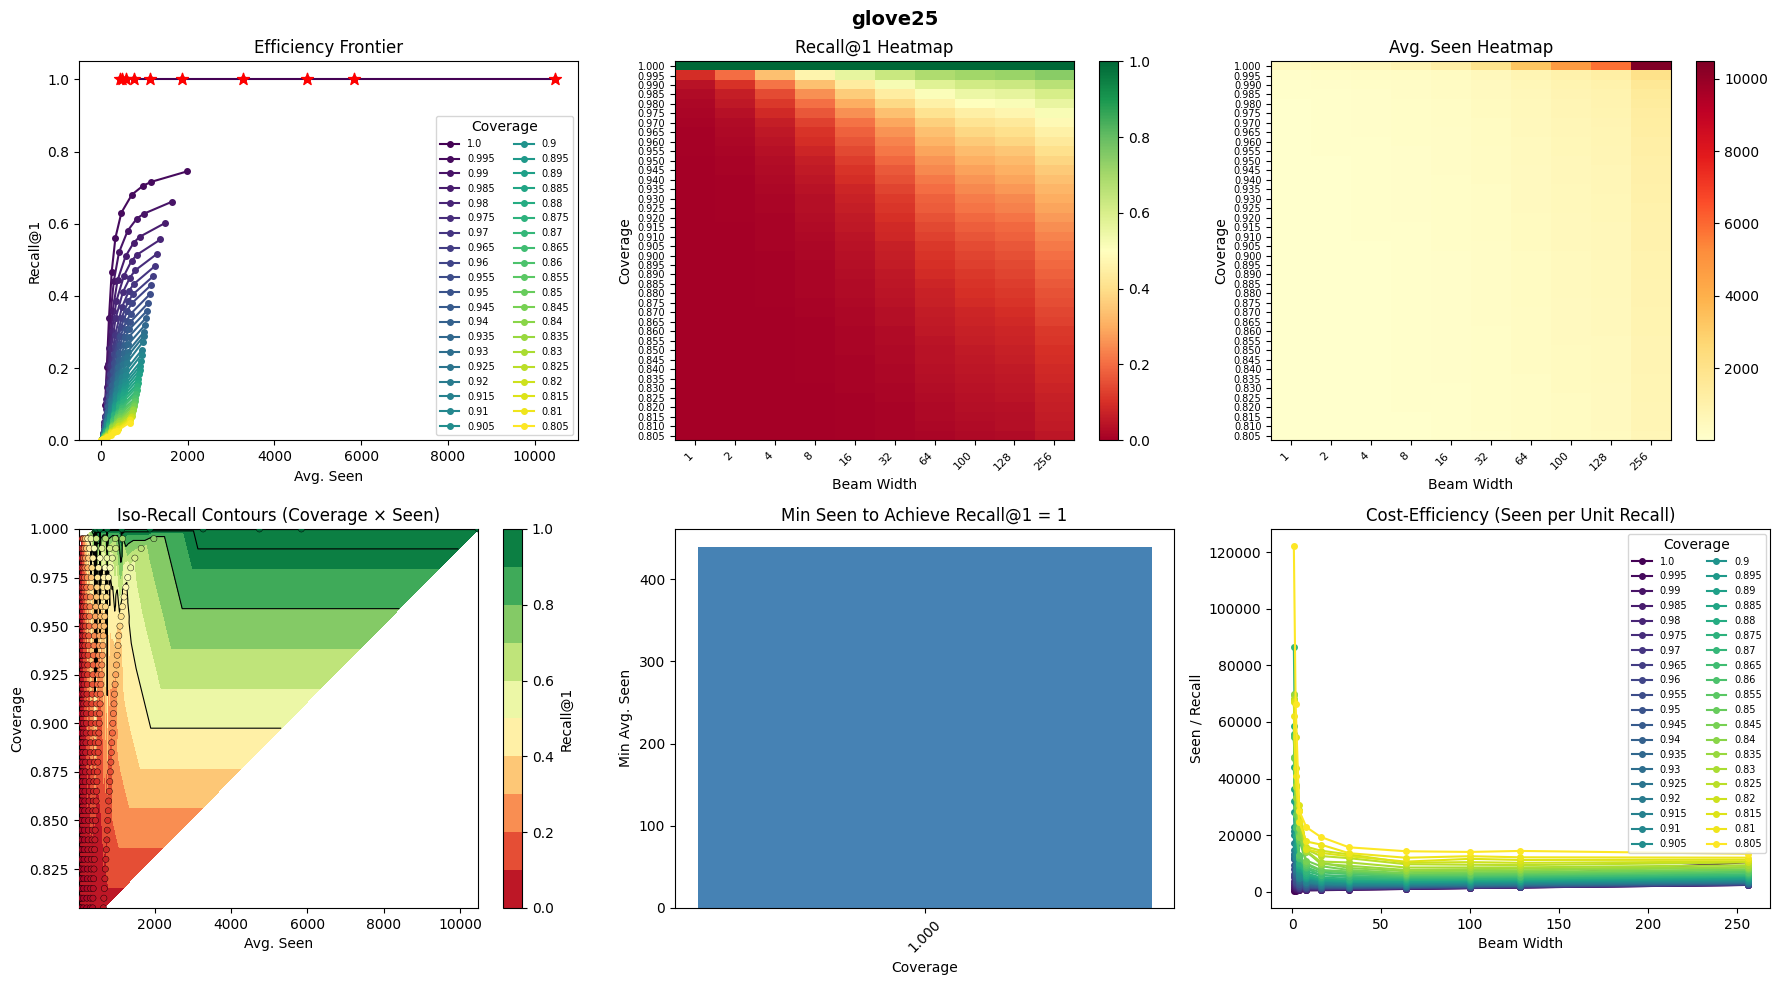

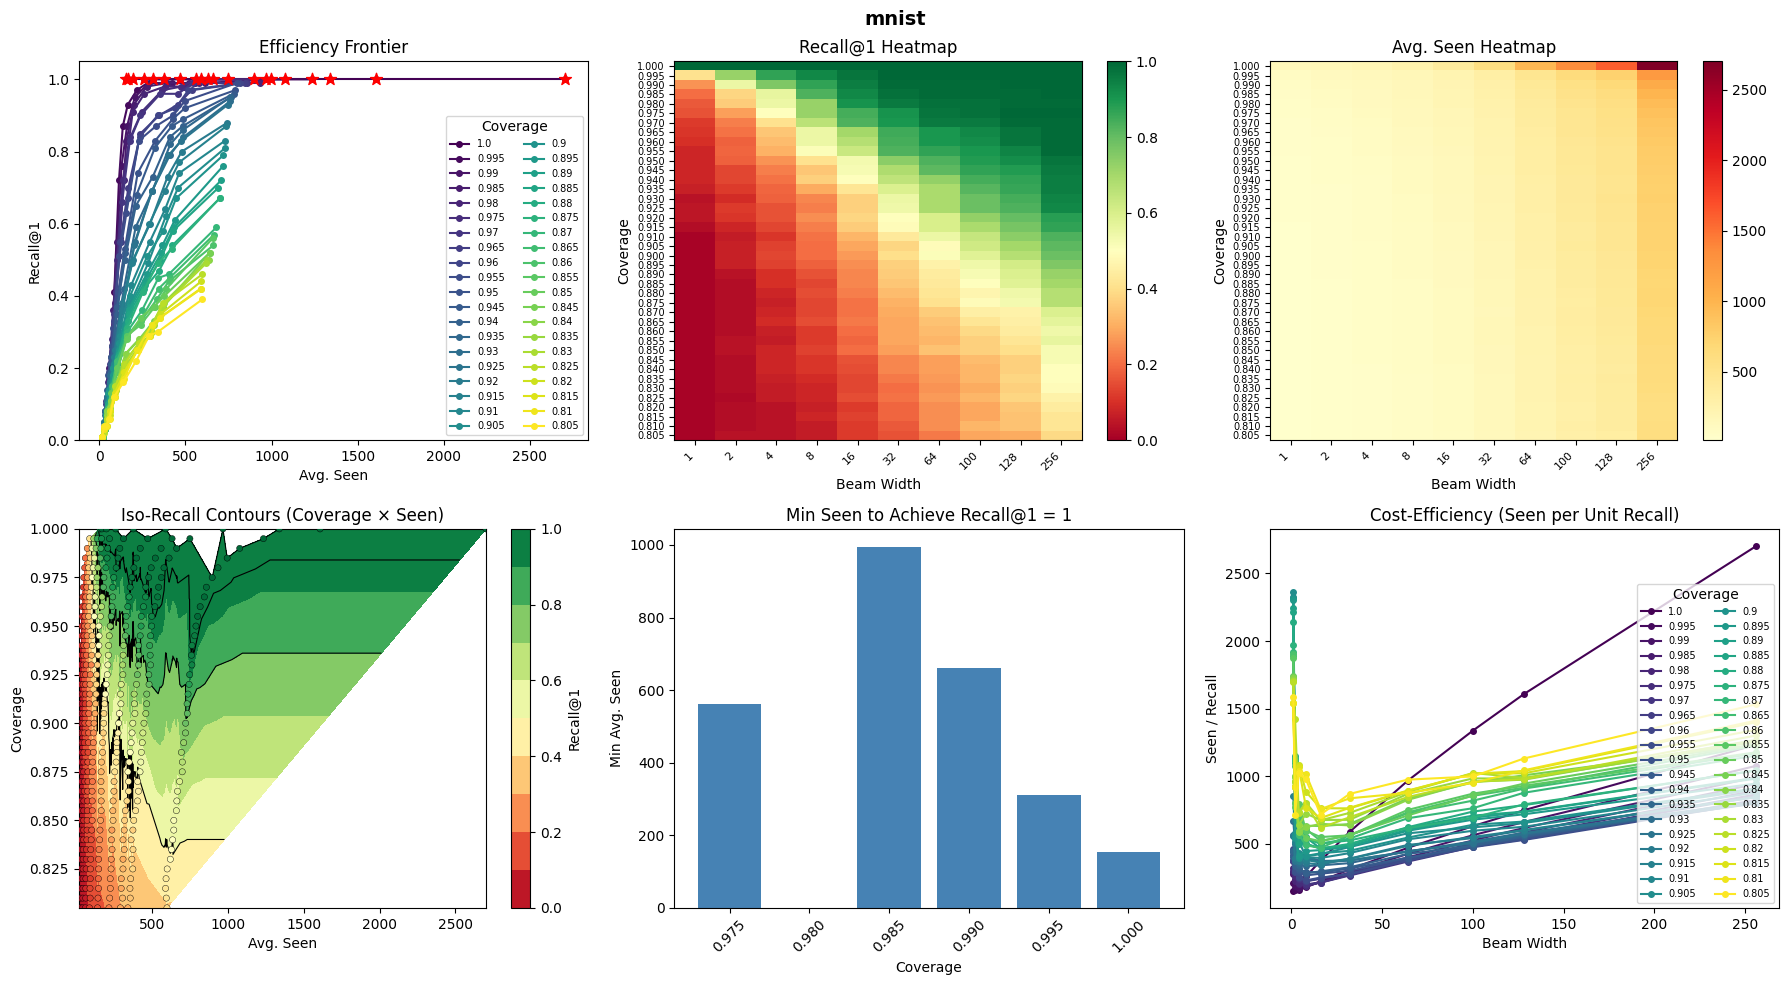

In [13]:
import re
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

K = 1
ds_df_k1 = df[(df['k'] == K) & (df['beam_width'] >= K)]

coverages_str = sorted(
    [re.search(r'avg_edges_(.+)', c).group(1) for c in df.columns if c.startswith('avg_edges_')],
    reverse=True
)
coverages_f = [float(c) for c in coverages_str]
cov_colors  = [cm.viridis(i / (len(coverages_str) - 1)) for i in range(len(coverages_str))]

for dataset, ds_df in ds_df_k1.groupby('dataset'):
    ds_df = ds_df.sort_values('beam_width')
    beam_widths = sorted(ds_df['beam_width'].unique())

    # long-form table: one row per (beam_width, coverage)
    rows = []
    for _, row in ds_df.iterrows():
        for c_str, c_f in zip(coverages_str, coverages_f):
            rows.append({
                'beam_width': row['beam_width'],
                'coverage':   c_f,
                'recall':     row[f'train_relevant_{c_str}'] / K,
                'seen':       row[f'train_seen_{c_str}'],
            })
    lf = pd.DataFrame(rows)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(dataset, fontsize=14, fontweight='bold')

    # 1 — Efficiency frontier: recall vs seen, one line per coverage
    ax = axes[0, 0]
    for c_str, c_f, color in zip(coverages_str, coverages_f, cov_colors):
        sub = lf[lf['coverage'] == c_f].sort_values('beam_width')
        xs, ys = sub['seen'].values, sub['recall'].values
        ax.plot(xs, ys, color=color, linewidth=1.5, marker='o', ms=4, label=c_str)
        stars = ys >= 1
        if stars.any():
            ax.scatter(xs[stars], ys[stars], marker='*', color='red', s=80, zorder=6)
    ax.set_xlabel('Avg. Seen'); ax.set_ylabel('Recall@1')
    ax.set_ylim(0, 1.05); ax.set_title('Efficiency Frontier')
    ax.legend(title='Coverage', fontsize=7, ncol=2)

    # 2a — Heatmap: beam_width × coverage → recall
    ax = axes[0, 1]
    pivot_r = lf.pivot(index='coverage', columns='beam_width', values='recall').sort_index()
    im = ax.imshow(pivot_r.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='lower')
    ax.set_xticks(range(len(beam_widths))); ax.set_xticklabels(beam_widths, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot_r.index))); ax.set_yticklabels([f'{v:.3f}' for v in pivot_r.index], fontsize=7)
    ax.set_xlabel('Beam Width'); ax.set_ylabel('Coverage'); ax.set_title('Recall@1 Heatmap')
    plt.colorbar(im, ax=ax)

    # 2b — Heatmap: beam_width × coverage → seen
    ax = axes[0, 2]
    pivot_s = lf.pivot(index='coverage', columns='beam_width', values='seen').sort_index()
    im2 = ax.imshow(pivot_s.values, aspect='auto', cmap='YlOrRd', origin='lower')
    ax.set_xticks(range(len(beam_widths))); ax.set_xticklabels(beam_widths, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot_s.index))); ax.set_yticklabels([f'{v:.3f}' for v in pivot_s.index], fontsize=7)
    ax.set_xlabel('Beam Width'); ax.set_ylabel('Coverage'); ax.set_title('Avg. Seen Heatmap')
    plt.colorbar(im2, ax=ax)

    # 3 — Iso-recall contours on Coverage × Seen space
    ax = axes[1, 0]
    xs, ys, zs = lf['seen'].values, lf['coverage'].values, lf['recall'].values
    tcf = ax.tricontourf(xs, ys, zs, levels=np.linspace(0, 1, 11), cmap='RdYlGn')
    ax.tricontour(xs, ys, zs, levels=[0.5, 0.8, 0.95, 1.0], colors='black', linewidths=0.8)
    ax.scatter(xs, ys, c=zs, cmap='RdYlGn', vmin=0, vmax=1, s=20, edgecolors='k', linewidths=0.3, zorder=5)
    plt.colorbar(tcf, ax=ax, label='Recall@1')
    ax.set_xlabel('Avg. Seen'); ax.set_ylabel('Coverage')
    ax.set_title('Iso-Recall Contours (Coverage × Seen)')

    # 4 — Min seen to reach recall = 1, per coverage
    ax = axes[1, 1]
    cov_asc = sorted(zip(coverages_f, coverages_str))
    min_seen = [lf[(lf['coverage'] == c_f) & (lf['recall'] >= 1.0)]['seen'].min()
                for c_f, _ in cov_asc]
    ax.bar([f'{c_f:.3f}' for c_f, _ in cov_asc], min_seen, color='steelblue')
    ax.set_xlabel('Coverage'); ax.set_ylabel('Min Avg. Seen')
    ax.set_title('Min Seen to Achieve Recall@1 = 1')
    ax.tick_params(axis='x', rotation=45)

    # 5 — Cost-efficiency: seen/recall vs beam_width, lines per coverage
    ax = axes[1, 2]
    for c_str, c_f, color in zip(coverages_str, coverages_f, cov_colors):
        sub = lf[(lf['coverage'] == c_f) & (lf['recall'] > 0)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['seen'] / sub['recall'],
                color=color, linewidth=1.5, marker='o', ms=4, label=c_str)
    ax.set_xlabel('Beam Width'); ax.set_ylabel('Seen / Recall')
    ax.set_title('Cost-Efficiency (Seen per Unit Recall)')
    ax.legend(title='Coverage', fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()


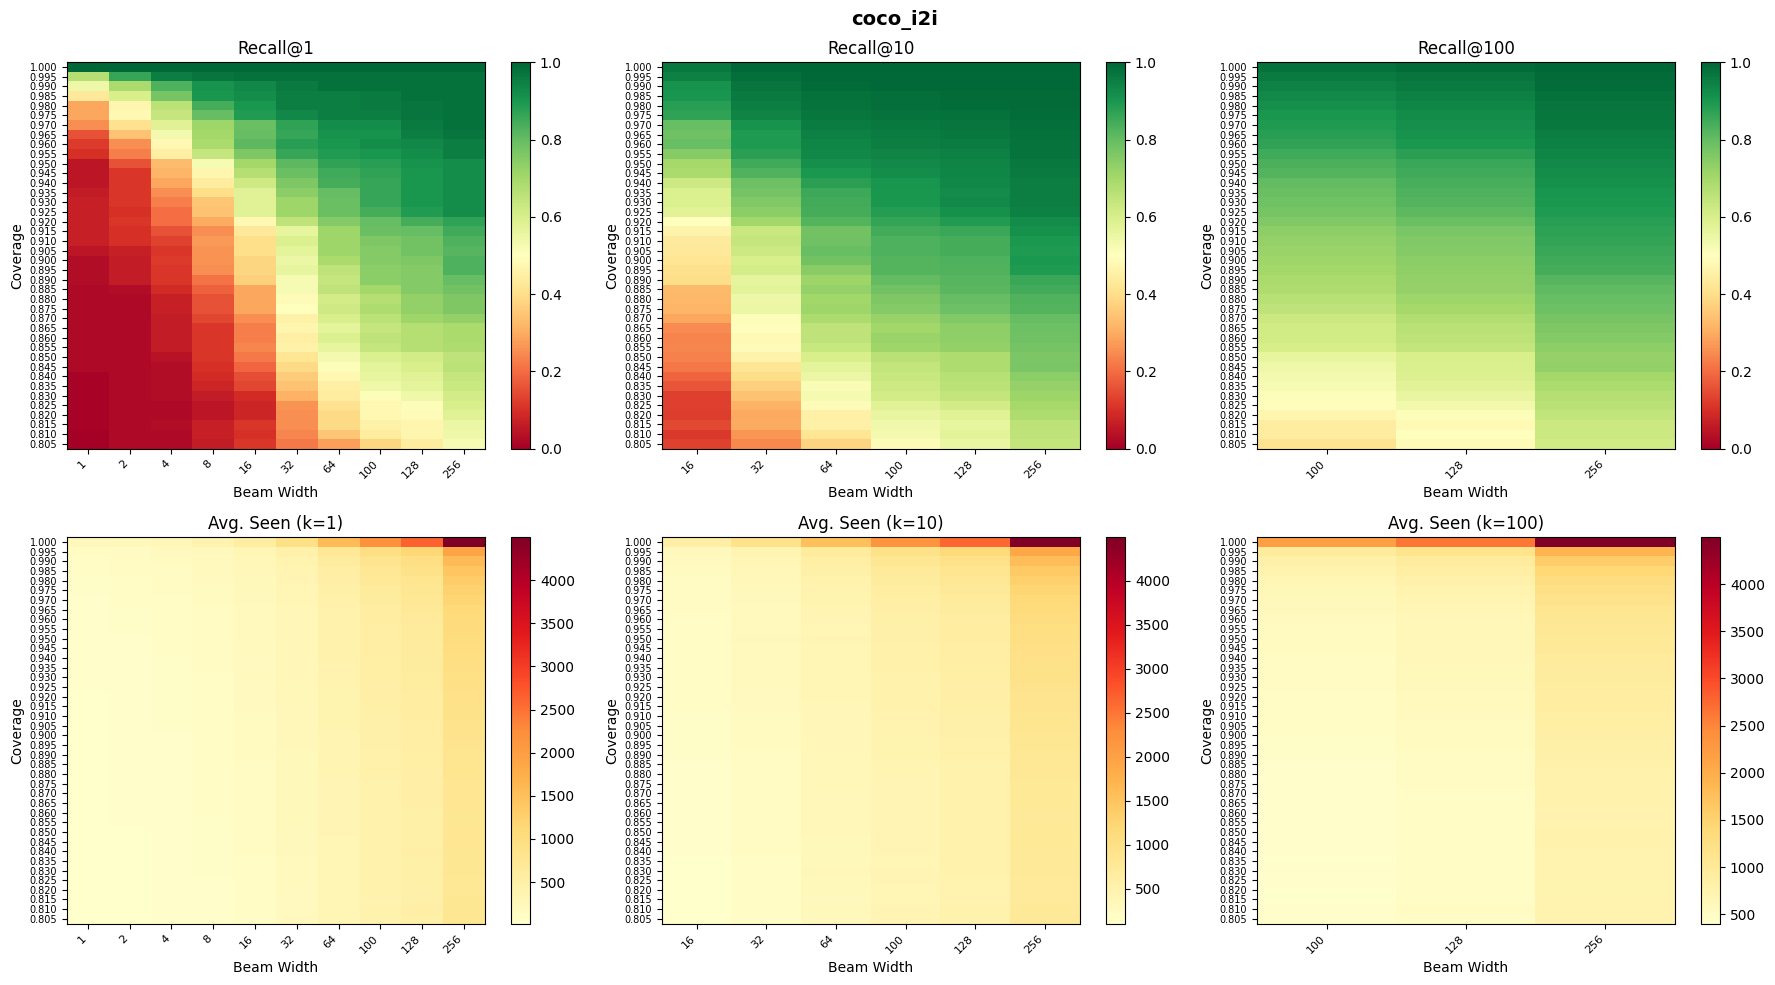

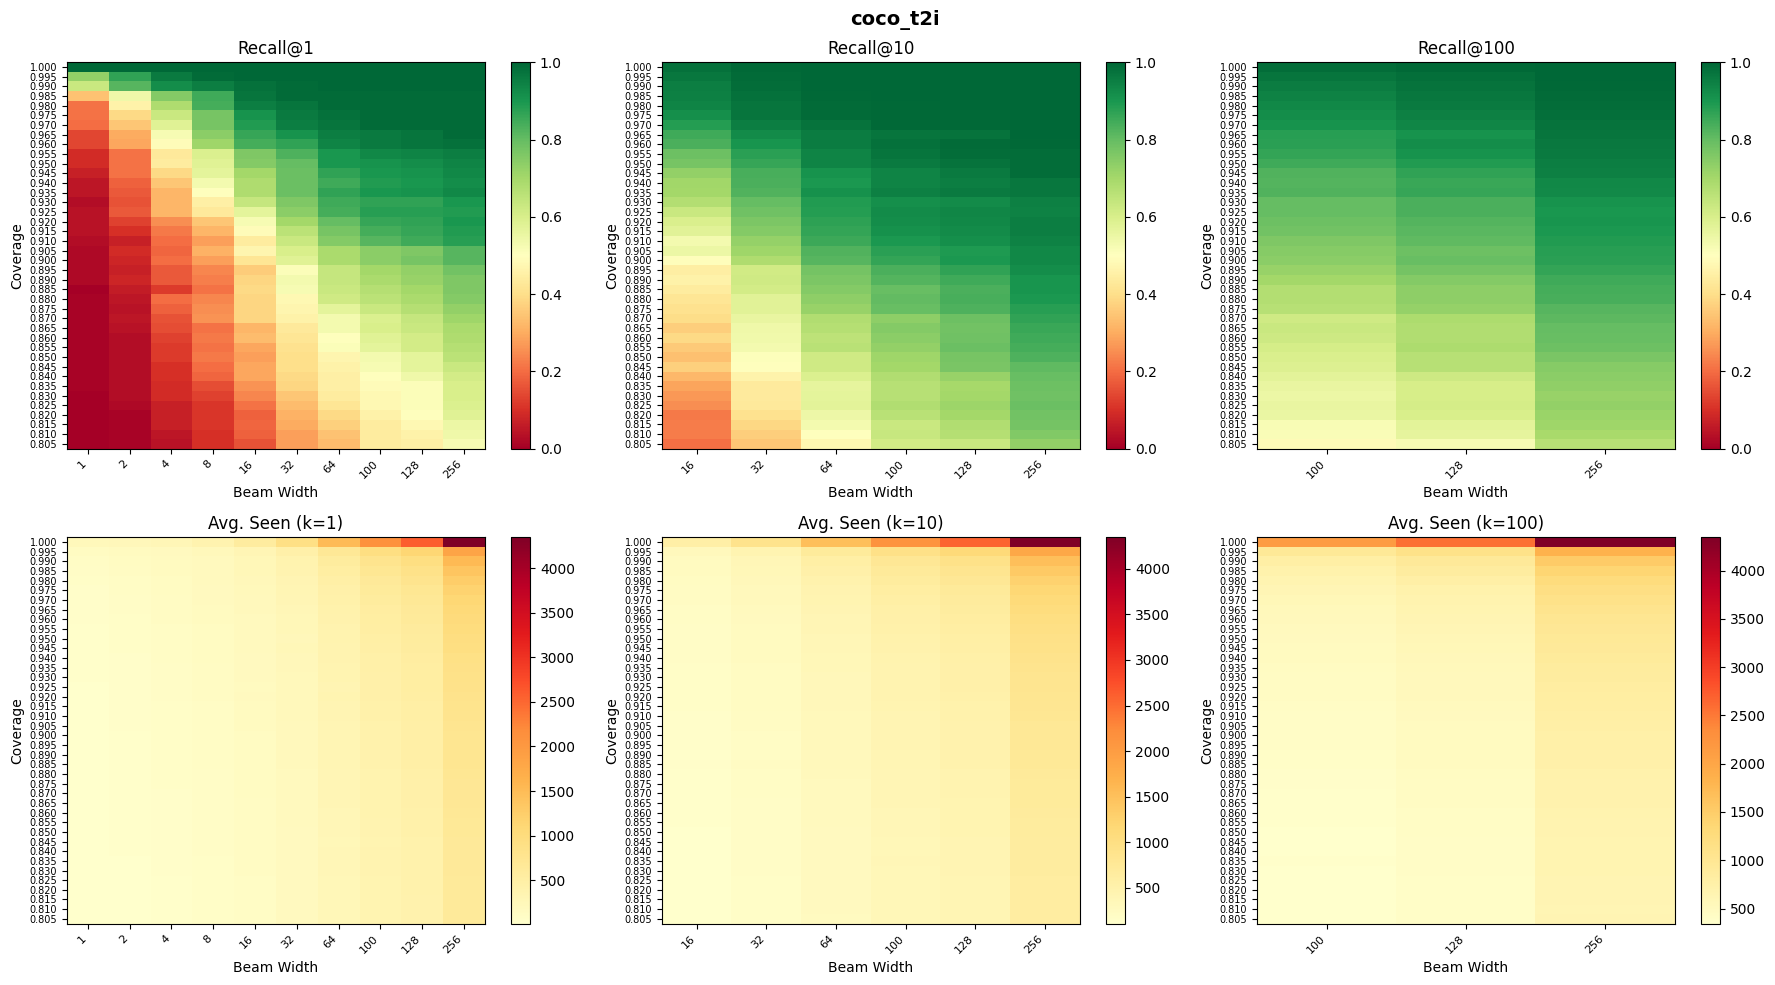

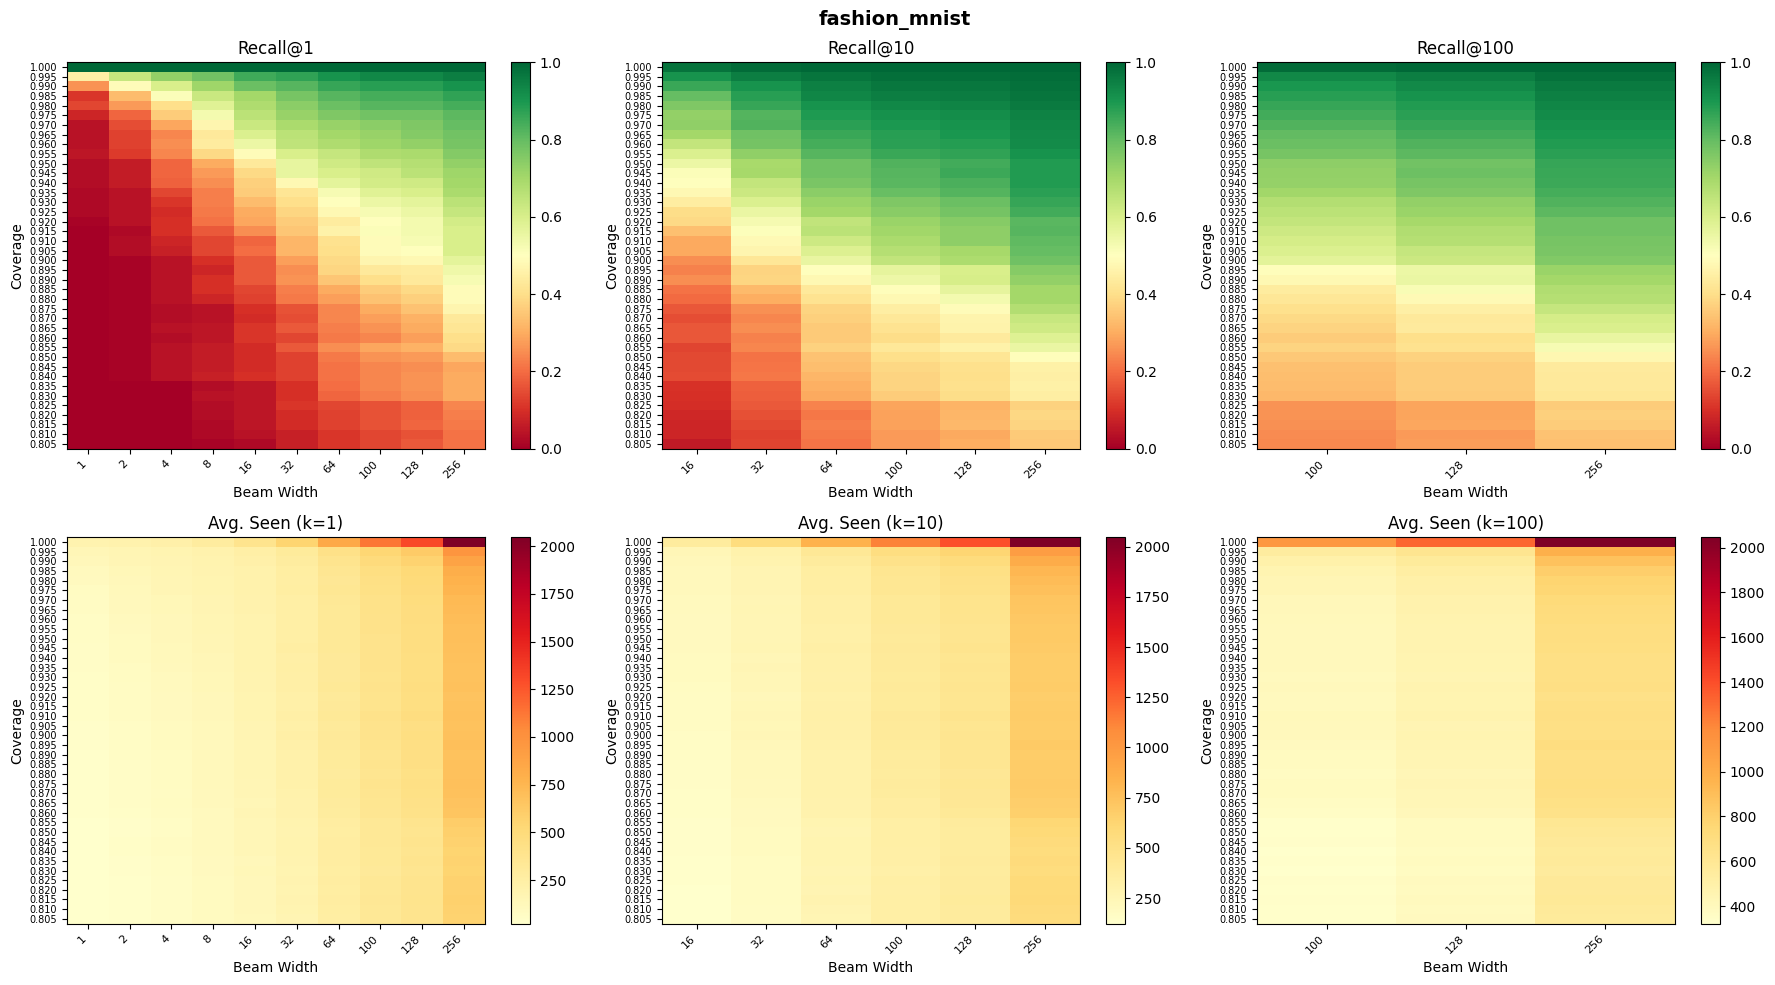

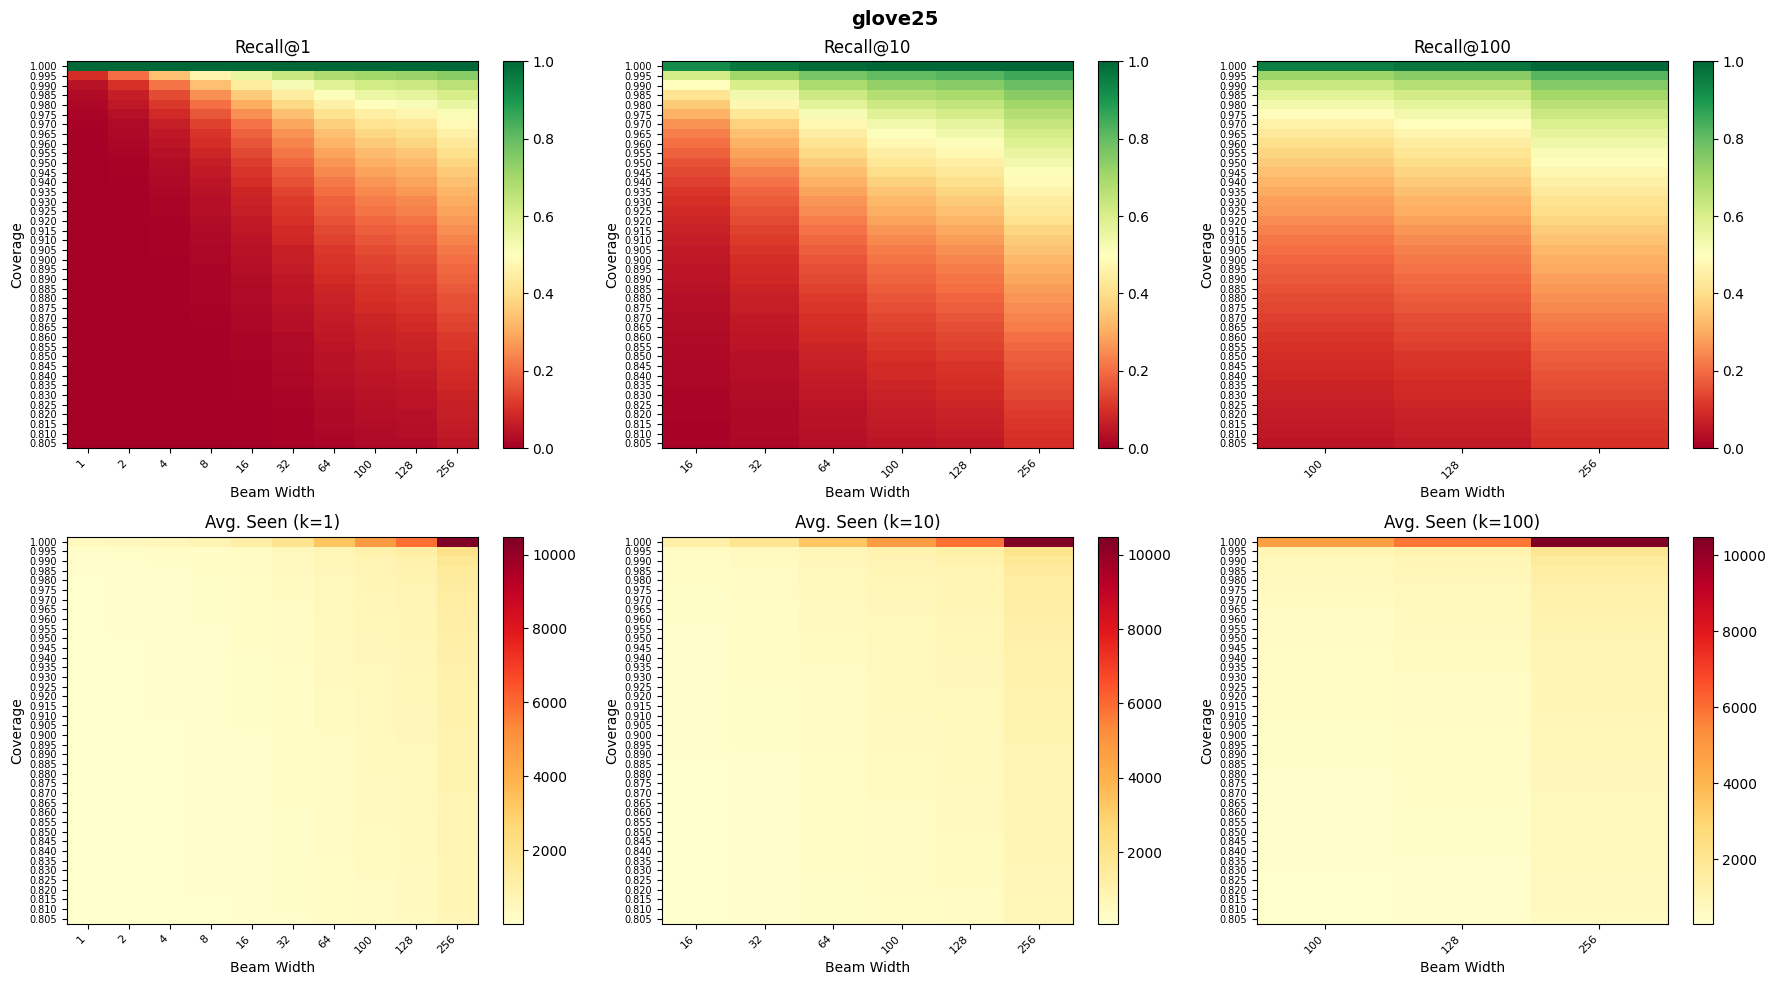

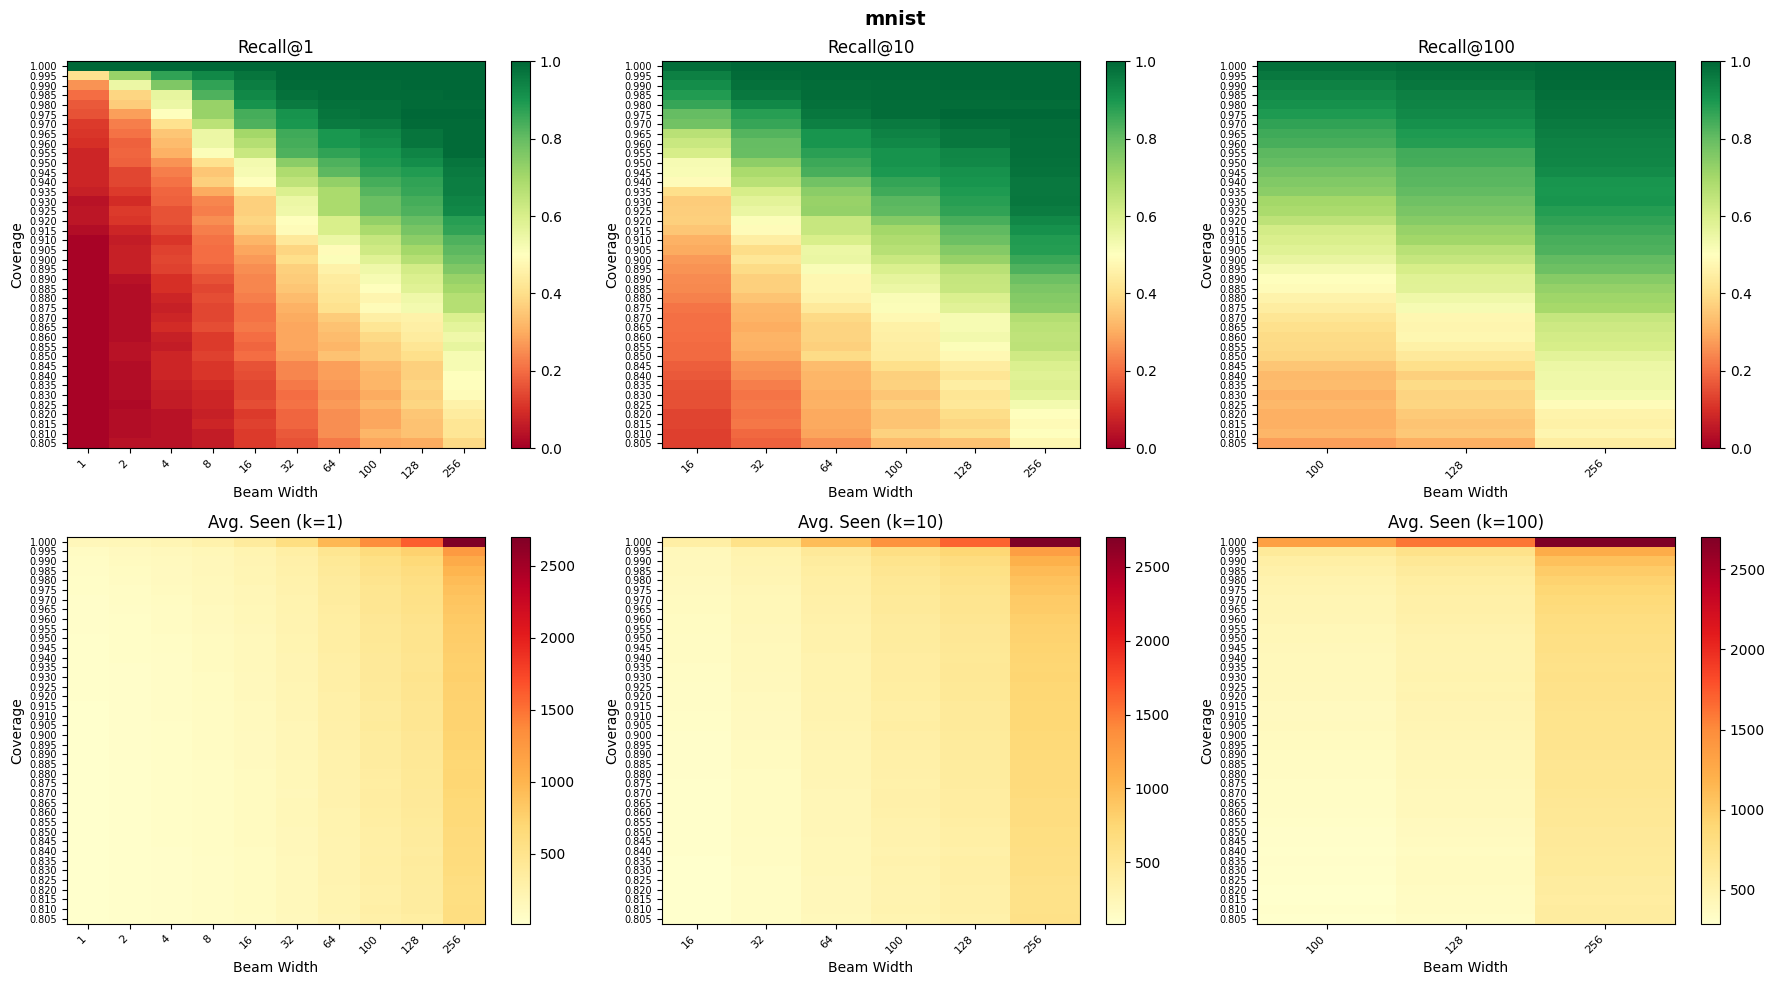

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt

KS = [1, 10, 100]

coverages_str = sorted(
    [re.search(r'avg_edges_(.+)', c).group(1) for c in df.columns if c.startswith('avg_edges_')],
    reverse=True
)
coverages_f = [float(c) for c in coverages_str]

for dataset, ds_df in df.groupby('dataset'):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(dataset, fontsize=14, fontweight='bold')

    for col_idx, k in enumerate(KS):
        k_df = ds_df[(ds_df['k'] == k) & (ds_df['beam_width'] >= k)].sort_values('beam_width')
        if k_df.empty:
            axes[0, col_idx].set_visible(False)
            axes[1, col_idx].set_visible(False)
            continue

        beam_widths = sorted(k_df['beam_width'].unique())

        rows = []
        for _, row in k_df.iterrows():
            for c_str, c_f in zip(coverages_str, coverages_f):
                rows.append({
                    'beam_width': row['beam_width'],
                    'coverage':   c_f,
                    'recall':     row[f'train_relevant_{c_str}'] / k,
                    'seen':       row[f'train_seen_{c_str}'],
                })
        lf = pd.DataFrame(rows)

        # Row 0: Recall@k heatmap
        ax = axes[0, col_idx]
        pivot_r = lf.pivot(index='coverage', columns='beam_width', values='recall').sort_index()
        bws = sorted(pivot_r.columns)
        im = ax.imshow(pivot_r[bws].values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='lower')
        ax.set_xticks(range(len(bws)))
        ax.set_xticklabels(bws, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(pivot_r.index)))
        ax.set_yticklabels([f'{v:.3f}' for v in pivot_r.index], fontsize=7)
        ax.set_xlabel('Beam Width')
        ax.set_ylabel('Coverage')
        ax.set_title(f'Recall@{k}')
        plt.colorbar(im, ax=ax)

        # Row 1: Avg. Seen heatmap
        ax = axes[1, col_idx]
        pivot_s = lf.pivot(index='coverage', columns='beam_width', values='seen').sort_index()
        im2 = ax.imshow(pivot_s[bws].values, aspect='auto', cmap='YlOrRd', origin='lower')
        ax.set_xticks(range(len(bws)))
        ax.set_xticklabels(bws, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(pivot_s.index)))
        ax.set_yticklabels([f'{v:.3f}' for v in pivot_s.index], fontsize=7)
        ax.set_xlabel('Beam Width')
        ax.set_ylabel('Coverage')
        ax.set_title(f'Avg. Seen (k={k})')
        plt.colorbar(im2, ax=ax)

    plt.tight_layout()
    plt.show()

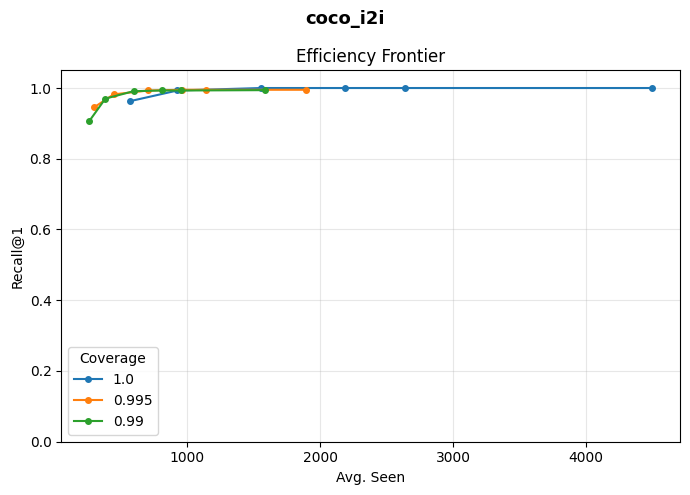

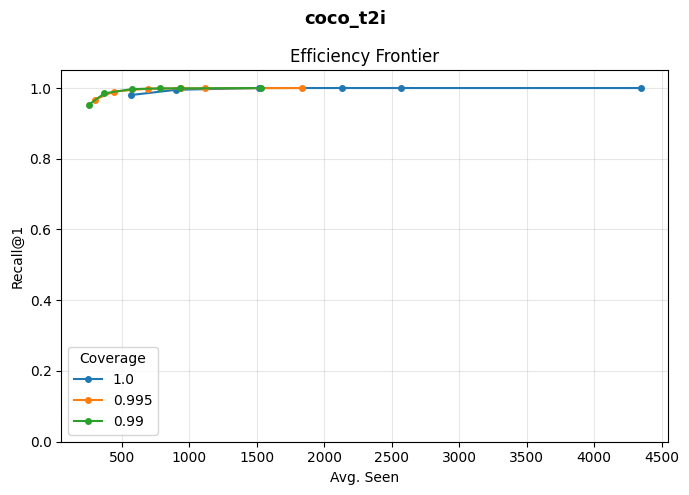

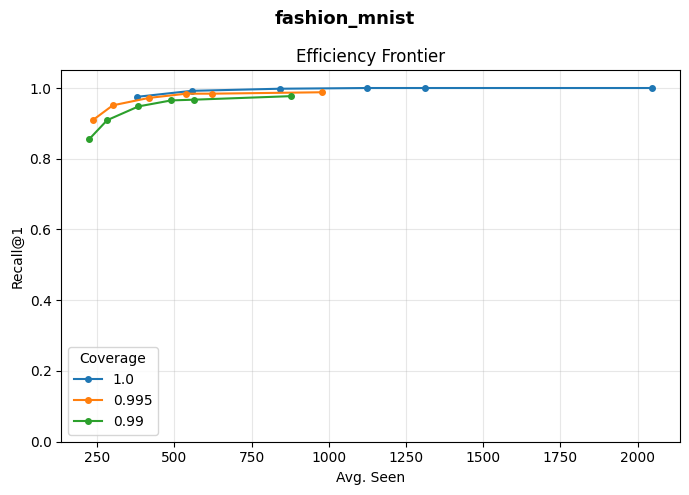

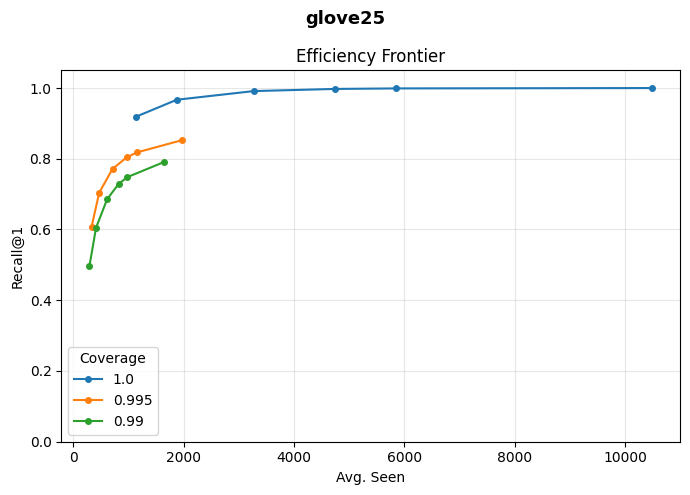

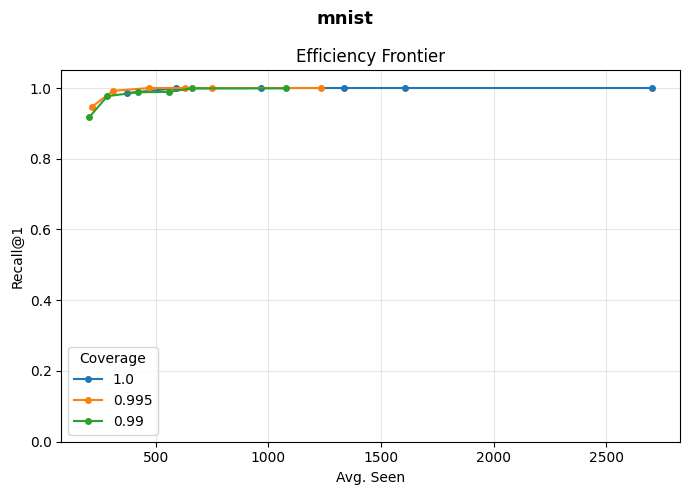

In [ ]:
#TODO: beam_width + coverage combination that allows us to beat full navigability on distance computations. Do it for test queries 
import re
import numpy as np
import matplotlib.pyplot as plt

K = 10
TARGET_COVERAGES = {1.0, 0.995, 0.99}
COLORS = {1.0: 'tab:blue', 0.995: 'tab:orange', 0.99: 'tab:green'}

ds_df_k1 = df[(df['k'] == K) & (df['beam_width'] >= K)]

coverages_str = sorted(
    [re.search(r'avg_edges_(.+)', c).group(1) for c in df.columns if c.startswith('avg_edges_')],
    reverse=True
)
coverages_f = [float(c) for c in coverages_str]

for dataset, ds_df in ds_df_k1.groupby('dataset'):
    rows = []
    for _, row in ds_df.sort_values('beam_width').iterrows():
        for c_str, c_f in zip(coverages_str, coverages_f):
            if any(abs(c_f - t) < 1e-9 for t in TARGET_COVERAGES):
                rows.append({
                    'beam_width': row['beam_width'],
                    'coverage':   c_f,
                    'recall':     row[f'train_relevant_{c_str}'] / K,
                    'seen':       row[f'train_seen_{c_str}'],
                })
    lf = pd.DataFrame(rows)
    if lf.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(dataset, fontsize=13, fontweight='bold')

    for c_f in sorted(TARGET_COVERAGES, reverse=True):
        sub = lf[lf['coverage'] == c_f].sort_values('beam_width')
        if sub.empty:
            continue
        xs, ys = sub['seen'].values, sub['recall'].values
        ax.plot(xs, ys, color=COLORS[c_f], linewidth=1.5, marker='o', ms=4, label=f'{c_f}')
        stars = ys >= 1
        # if stars.any():
            # ax.scatter(xs[stars], ys[stars], marker='*', color='red', s=80, zorder=6)

    ax.set_xlabel('Avg. Seen')
    ax.set_ylabel('Recall@1')
    ax.set_ylim(0, 1.05)
    ax.set_title('Efficiency Frontier')
    ax.legend(title='Coverage')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
